# BUS 659: Machine Learning for Managers
## MIDTERM EXAM VERSION 2 (Take-Home, 72 Hours)

**Instructions:**
- This is a take-home exam to be completed within 72 hours of receipt
- You may use all course materials, notes, and online resources
- You must work independently - no collaboration with other students
- Submit your completed Jupyter notebook with all code executed and outputs visible
- Each question builds in complexity; partial credit will be given for attempted work
- Save your work frequently

**Datasets:** 
- Question 1: `../datasets/digital_advertising_campaigns.csv`
- Question 2: `../datasets/career_outcomes_survey.csv`

**Total Points:** 100 (50 per question)

**Academic Integrity Statement:** By submitting this exam, I affirm that all work is my own and I have neither given nor received unauthorized assistance.

# Matthew Tonks

In [67]:
# NAME: Matthew Tonks
# DATE: 2025-10-01

# I affirm that this work is entirely my own:
# SIGNATURE: Matthew Tonks

# I affirm that if I consulted AI models I typed their outputs on my own instead of copy/paste 
# SIGNATURE: Matthew Tonks

In [68]:
# Setup - DO NOT MODIFY THIS CELL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotnine import *
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-darkgrid')

print("Setup complete. You may begin.")

Setup complete. You may begin.


---
# QUESTION 1: Digital Advertising Campaign Analysis & Optimization (50 points)

You are a data analyst at a Fortune 500 company that spends $50M annually on digital advertising across multiple channels. The CMO has asked you to analyze the company's advertising campaigns to optimize spending and improve ROI.

**Dataset Description:** `digital_advertising_campaigns.csv` contains:
- `campaign_id`: Unique identifier for each campaign
- `campaign_date`: Date the campaign was launched
- `platform`: Advertising platform (Google, Facebook, Instagram, LinkedIn, Twitter, TikTok)
- `ad_type`: Type of ad (Video, Display, Search, Social, Native)
- `target_audience`: Target demographic (18-24, 25-34, 35-44, 45-54, 55+)
- `industry_vertical`: Product category being advertised
- `campaign_duration_days`: Length of campaign
- `ad_spend`: Total amount spent on the campaign (USD)
- `impressions`: Number of times the ad was shown
- `clicks`: Number of clicks on the ad
- `conversions`: Number of desired actions taken (purchases, signups, etc.)
- `revenue_generated`: Revenue attributed to the campaign (USD)
- `device_type`: Primary device type (Mobile, Desktop, Tablet)
- `geographic_region`: Region targeted (North America, Europe, Asia, etc.)
- `seasonality`: Quarter of the year (Q1, Q2, Q3, Q4)
- `creative_score`: Internal quality score of ad creative (1-100)

## Q1.a) Data Exploration and Quality Assessment (5 points)

1. Load the advertising dataset and check for data quality issues:
   - Display shape, data types, and missing values
   - Check for duplicate campaign_ids
   - Identify any logical inconsistencies (e.g., clicks > impressions, conversions > clicks)
   
2. Create efficiency metrics:
   - `CPM` (Cost per thousand impressions): (ad_spend / impressions) * 1000
   - `CTR` (Click-through rate): clicks / impressions
   - `conversion_rate`: conversions / clicks  
   - `ROAS` (Return on ad spend): revenue_generated / ad_spend
   - `profit_margin`: (revenue_generated - ad_spend) / revenue_generated
   
3. Remove problematic records and campaigns with impressions < 500

4. Create a correlation heatmap of all numeric variables and identify the top 3 correlations

(5000, 16)
Data types, missing values, and unique counts:


,data_type,missing,unique_values
campaign_id,object,0,5000
campaign_date,object,0,5000
platform,object,0,6
ad_type,object,0,5
target_audience,object,0,5
industry_vertical,object,0,7
campaign_duration_days,int64,0,5
device_type,object,0,3
geographic_region,object,0,5
seasonality,object,0,4


Quality checks:


,issue,count
0,duplicate_campaign_ids,0
1,clicks_gt_impressions,0
2,conversions_gt_clicks,0
3,impressions_lt_500,0
4,zero_ad_spend,0
5,zero_revenue,0


Rows removed for logical issues: 0 (cleaned dataset: 5,000 rows)


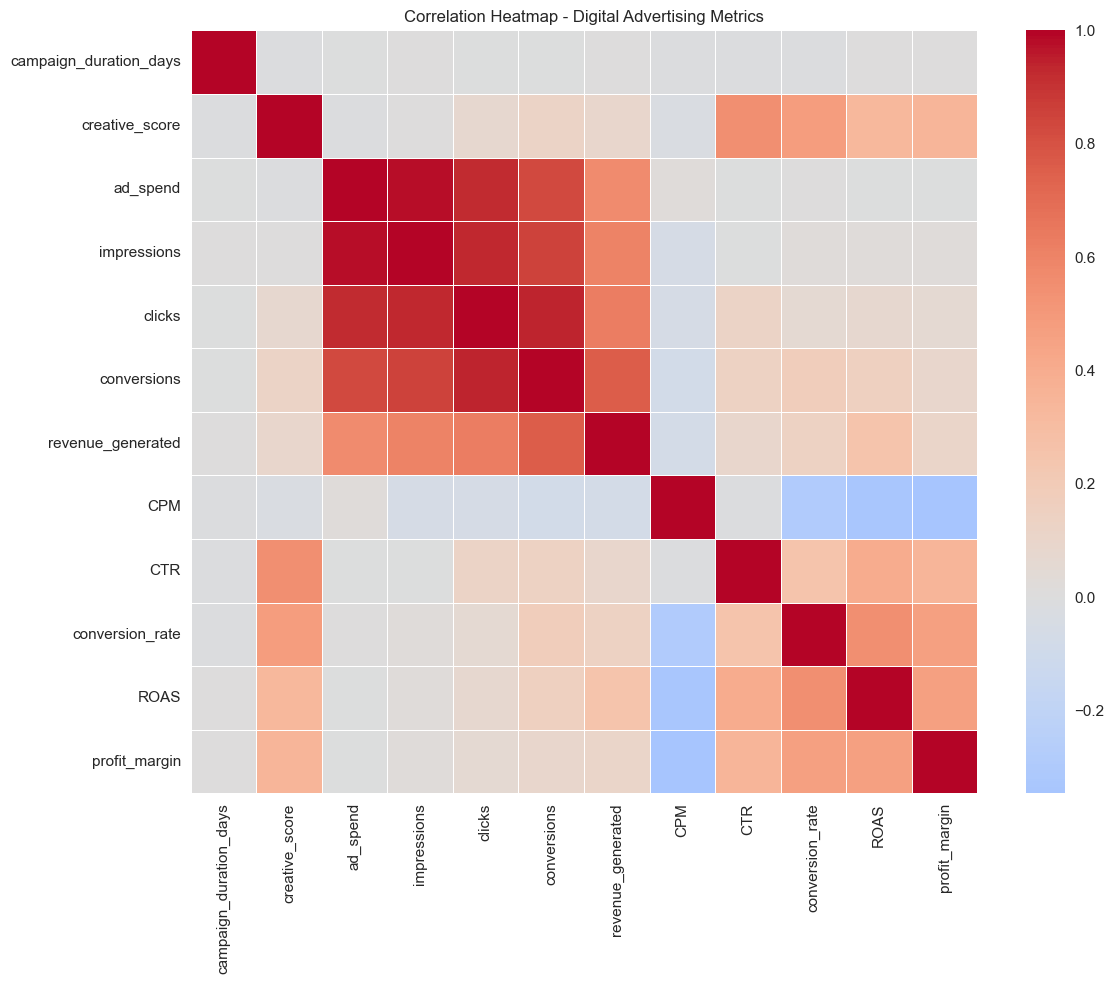

In [69]:
ad_df = pd.read_csv('datasets/digital_advertising_campaigns.csv')
print(ad_df.shape)

summary_df = pd.DataFrame({
    'data_type': ad_df.dtypes,
    'missing': ad_df.isna().sum(),
    'unique_values': ad_df.nunique()
})
print('Data types, missing values, and unique counts:')
display(summary_df)

quality_checks = pd.DataFrame([
    ('duplicate_campaign_ids', ad_df['campaign_id'].duplicated().sum()),
    ('clicks_gt_impressions', int((ad_df['clicks'] > ad_df['impressions']).sum())),
    ('conversions_gt_clicks', int((ad_df['conversions'] > ad_df['clicks']).sum())),
    ('impressions_lt_500', int((ad_df['impressions'] < 500).sum())),
    ('zero_ad_spend', int((ad_df['ad_spend'] <= 0).sum())),
    ('zero_revenue', int((ad_df['revenue_generated'] <= 0).sum()))
], columns=['issue', 'count'])
print('Quality checks:')
display(quality_checks)

# Efficiency metrics
ad_df['CPM'] = np.where(ad_df['impressions'] > 0, ad_df['ad_spend'] / ad_df['impressions'] * 1000, np.nan)
ad_df['CTR'] = np.where(ad_df['impressions'] > 0, ad_df['clicks'] / ad_df['impressions'], np.nan)
ad_df['conversion_rate'] = np.where(ad_df['clicks'] > 0, ad_df['conversions'] / ad_df['clicks'], np.nan)
ad_df['ROAS'] = np.where(ad_df['ad_spend'] > 0, ad_df['revenue_generated'] / ad_df['ad_spend'], np.nan)
ad_df['profit_margin'] = np.where(ad_df['revenue_generated'] > 0,
                                  (ad_df['revenue_generated'] - ad_df['ad_spend']) / ad_df['revenue_generated'],
                                  np.nan)

logic_mask = (
    (ad_df['clicks'] <= ad_df['impressions']) &
    (ad_df['conversions'] <= ad_df['clicks']) &
    (ad_df['impressions'] >= 500)
)
removed_records = (~logic_mask).sum()
ad_df = ad_df.loc[logic_mask].reset_index(drop=True)
print(f'Rows removed for logical issues: {removed_records} (cleaned dataset: {len(ad_df):,} rows)')

numeric_cols = ad_df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = ad_df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap - Digital Advertising Metrics')
plt.tight_layout()
plt.show()

## Q1.b) Time Series and Trend Analysis (8 points)

1. Convert campaign_date to datetime and extract temporal features:
   - Year, month, day of week, week of year
   - Is it a weekend campaign? (Saturday/Sunday)
   - Days since first campaign in dataset
   
2. Analyze performance trends over time:
   - Calculate monthly average ROAS, spend, and conversion rates
   - Compute 30-day and 90-day moving averages for ROAS
   - Identify months with significant performance changes (>20% from previous)
   - Which months perform best/worst and why?
   
3. Platform evolution analysis:
   - How has each platform's market share (% of total spend) changed over time?
   - Create a stacked area chart showing monthly spend distribution by platform
   - Which platforms are gaining/losing market share?
   - Calculate the trend (increasing/decreasing) for each platform's ROAS

In [70]:
# Q1.b - PART 1: Convert campaign_date and extract temporal features

ad_df['campaign_date'] = pd.to_datetime(ad_df['campaign_date'])
ad_df['campaign_year'] = ad_df['campaign_date'].dt.year
ad_df['campaign_month'] = ad_df['campaign_date'].dt.month
ad_df['day_of_week'] = ad_df['campaign_date'].dt.day_name()
ad_df['week_of_year'] = ad_df['campaign_date'].dt.isocalendar().week.astype(int)
ad_df['is_weekend'] = (ad_df['campaign_date'].dt.dayofweek >= 5).astype(int)
ad_df['days_since_first'] = (ad_df['campaign_date'] - ad_df['campaign_date'].min()).dt.days
ad_df['year_month'] = ad_df['campaign_date'].dt.to_period('M').dt.to_timestamp()


print("Temporal Features Created:")
print(ad_df[['campaign_date', 'campaign_year', 'campaign_month', 'day_of_week', 
            'week_of_year', 'is_weekend', 'days_since_first']].head(10))

Temporal Features Created:
                  campaign_date  campaign_year  campaign_month day_of_week  week_of_year  is_weekend  days_since_first
0 2022-01-01 00:00:00.000000000           2022               1    Saturday            52           1                 0
1 2022-01-01 04:57:51.094218843           2022               1    Saturday            52           1                 0
2 2022-01-01 09:55:42.188437687           2022               1    Saturday            52           1                 0
3 2022-01-01 14:53:33.282656531           2022               1    Saturday            52           1                 0
4 2022-01-01 19:51:24.376875375           2022               1    Saturday            52           1                 0
5 2022-01-02 00:49:15.471094218           2022               1      Sunday            52           1                 1
6 2022-01-02 05:47:06.565313062           2022               1      Sunday            52           1                 1
7 2022-01-02 10:44:57

Best-performing month: 2024-10 (ROAS = 11.32)
Worst-performing month: 2022-09 (ROAS = 7.19)
Months with >20% ROAS shift vs. prior month:


,year_month,avg_roas,roas_pct_change,total_spend
9,2022-10-01,8.935250,0.242051,4772893.67
21,2023-10-01,10.227796,0.213644,3507859.63
28,2024-05-01,9.466443,0.236361,3290914.64
33,2024-10-01,11.324822,0.200478,2586065.15


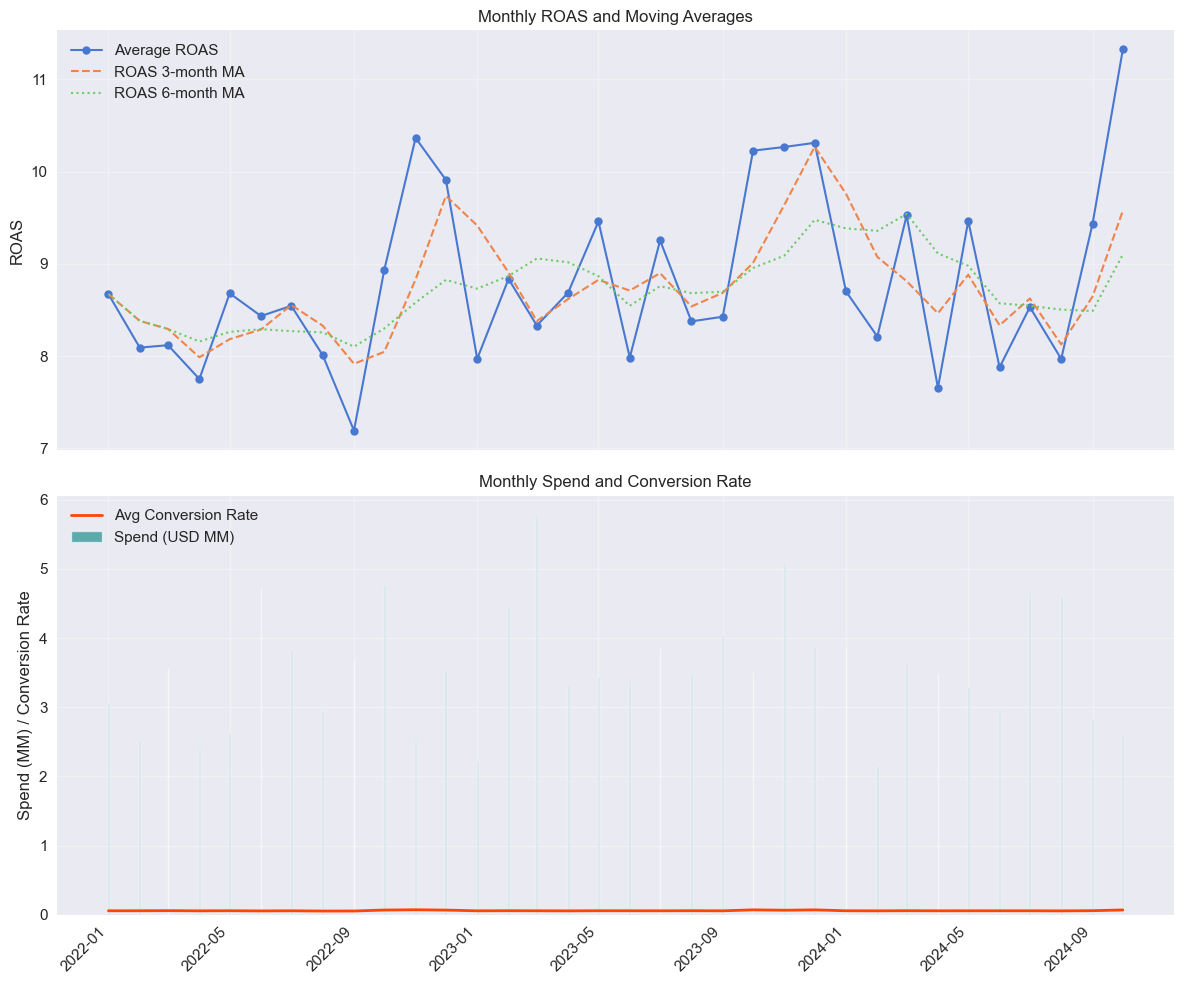

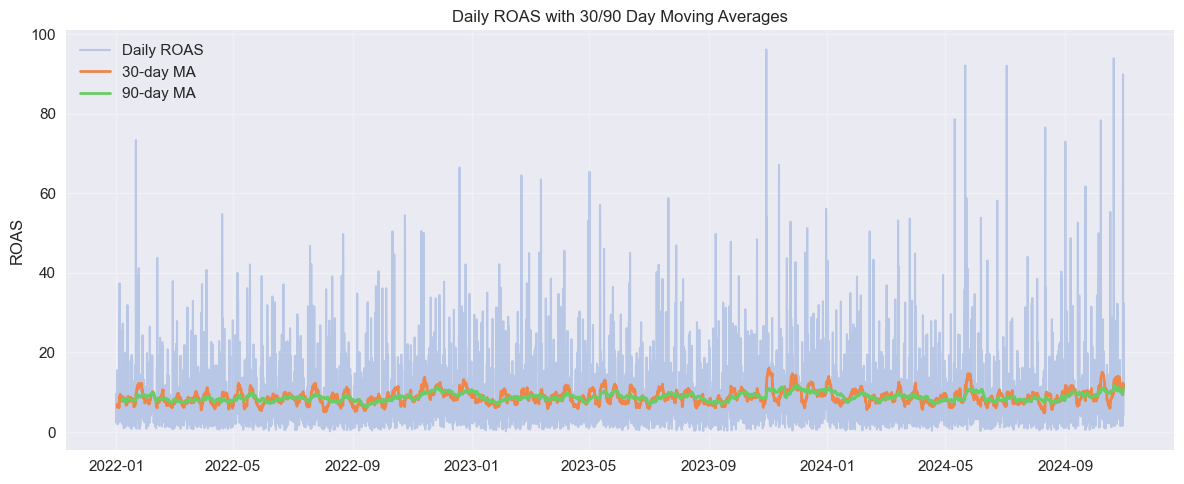

In [71]:
# Q1.b - PART 2: Analyze performance trends over time

monthly_metrics = ad_df.groupby('year_month').agg(
    avg_roas=('ROAS', 'mean'),
    total_spend=('ad_spend', 'sum'),
    avg_conversion_rate=('conversion_rate', 'mean'),
    avg_creative_score=('creative_score', 'mean')
).reset_index()
monthly_metrics['roas_pct_change'] = monthly_metrics['avg_roas'].pct_change()
monthly_metrics['spend_pct_change'] = monthly_metrics['total_spend'].pct_change()
monthly_metrics['conv_rate_pct_change'] = monthly_metrics['avg_conversion_rate'].pct_change()

best_month = monthly_metrics.loc[monthly_metrics['avg_roas'].idxmax()]
worst_month = monthly_metrics.loc[monthly_metrics['avg_roas'].idxmin()]
print(f"Best-performing month: {best_month['year_month'].strftime('%Y-%m')} (ROAS = {best_month['avg_roas']:.2f})")
print(f"Worst-performing month: {worst_month['year_month'].strftime('%Y-%m')} (ROAS = {worst_month['avg_roas']:.2f})")

shift_threshold = 0.20
significant_shifts = monthly_metrics.loc[monthly_metrics['roas_pct_change'].abs() > shift_threshold,
                                         ['year_month', 'avg_roas', 'roas_pct_change', 'total_spend']]
print('Months with >20% ROAS shift vs. prior month:')
display(significant_shifts)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
axes[0].plot(monthly_metrics['year_month'], monthly_metrics['avg_roas'], marker='o', label='Average ROAS')
axes[0].plot(monthly_metrics['year_month'], monthly_metrics['avg_roas'].rolling(window=3, min_periods=1).mean(),
             label='ROAS 3-month MA', linestyle='--')
axes[0].plot(monthly_metrics['year_month'], monthly_metrics['avg_roas'].rolling(window=6, min_periods=1).mean(),
             label='ROAS 6-month MA', linestyle=':')
axes[0].set_ylabel('ROAS')
axes[0].legend(loc='upper left')
axes[0].set_title('Monthly ROAS and Moving Averages')

axes[1].bar(monthly_metrics['year_month'], monthly_metrics['total_spend']/1e6, color='teal', alpha=0.6, label='Spend (USD MM)')
axes[1].plot(monthly_metrics['year_month'], monthly_metrics['avg_conversion_rate'], color='orangered', linewidth=2,
             label='Avg Conversion Rate')
axes[1].set_ylabel('Spend (MM) / Conversion Rate')
axes[1].legend(loc='upper left')
axes[1].set_title('Monthly Spend and Conversion Rate')
for ax in axes:
    ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

daily_perf = ad_df.groupby('campaign_date').agg(
    total_spend=('ad_spend', 'sum'),
    total_revenue=('revenue_generated', 'sum'),
    total_clicks=('clicks', 'sum'),
    total_conversions=('conversions', 'sum')
).sort_index()
daily_perf['daily_roas'] = daily_perf['total_revenue'] / daily_perf['total_spend']
daily_perf['roas_ma_30'] = daily_perf['daily_roas'].rolling(window=30, min_periods=7).mean()
daily_perf['roas_ma_90'] = daily_perf['daily_roas'].rolling(window=90, min_periods=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_perf.index, daily_perf['daily_roas'], alpha=0.3, label='Daily ROAS')
plt.plot(daily_perf.index, daily_perf['roas_ma_30'], label='30-day MA', linewidth=2)
plt.plot(daily_perf.index, daily_perf['roas_ma_90'], label='90-day MA', linewidth=2)
plt.title('Daily ROAS with 30/90 Day Moving Averages')
plt.ylabel('ROAS')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

There seems to be a trend for spending seems to be about the same with some growth on the Monthly ad spend is  fairly standard around a mean with a few peaks scattered. 

Over the holiday season (October, November, December) there is a seasonal trend where the values peak and then return to a standard baseline

In [72]:
# Platform share and ROAS trends
platform_monthly = ad_df.groupby(['year_month', 'platform']).agg(
    total_spend=('ad_spend', 'sum'),
    avg_roas=('ROAS', 'mean')
).reset_index()
platform_monthly['spend_share'] = platform_monthly.groupby('year_month')['total_spend'].transform(lambda x: x / x.sum())

platform_roas_summary = []
for platform, grp in platform_monthly.groupby('platform'):
    grp_sorted = grp.sort_values('year_month')
    share_change = (grp_sorted['spend_share'].iloc[-1] - grp_sorted['spend_share'].iloc[0]) * 100
    roas_slope = np.polyfit(np.arange(len(grp_sorted)), grp_sorted['avg_roas'], 1)[0]
    platform_roas_summary.append({
        'platform': platform,
        'start_share_%': grp_sorted['spend_share'].iloc[0] * 100,
        'end_share_%': grp_sorted['spend_share'].iloc[-1] * 100,
        'share_change_pp': share_change,
        'avg_roas': grp_sorted['avg_roas'].mean(),
        'roas_trend': 'Increasing' if roas_slope > 0 else 'Decreasing'
    })
platform_roas_summary = pd.DataFrame(platform_roas_summary).sort_values('share_change_pp', ascending=False)
print('Platform spend share & ROAS trend summary:')
display(platform_roas_summary)

import plotly.express as px
platform_area_fig = px.area(
    platform_monthly,
    x='year_month',
    y='total_spend',
    color='platform',
    groupnorm='fraction',
    title='Monthly Spend Distribution by Platform (Share of Wallet)'
)
platform_area_fig.update_layout(yaxis_tickformat='.0%', legend_title_text='Platform')
platform_area_fig.show()

Platform spend share & ROAS trend summary:


,platform,start_share_%,end_share_%,share_change_pp,avg_roas,roas_trend
4,TikTok,4.969673,15.009912,10.040240,6.380401,Decreasing
3,LinkedIn,9.223008,13.535642,4.312634,5.565161,Decreasing
0,Facebook,17.754080,19.414676,1.660596,10.245230,Increasing
2,Instagram,22.936877,23.119220,0.182343,7.949764,Increasing
1,Google,29.902510,23.977275,-5.925235,13.099437,Increasing
5,Twitter,15.213852,4.943275,-10.270577,3.931177,Increasing



1. Market Share (% of Spend) Over Time
	- Facebook & Google: The most stable spenders across the timeline, with periodic spikes. Google in captured a growing share after 2023, overtaking other platforms in several high-spend months.
	- Instagram: Volatile. It peaks strongly in mid-2022 and mid-2024 but sees contractions afterward, suggesting budget reallocation to better-performing channels.
	- LinkedIn: Consistently moderate contributor; share is steady but never dominant. It acts as a secondary spend channel.
	- TikTok: Noticeable ramp-up starting 2023, becoming a consistent middle-tier spender by 2024. Market share is rising, showing confidence in its ROI.
	- Twitter: Highly volatile — some peaks in 2022 and mid-2023 but declining share by late 2024. Looks like budgets are being shifted away.

2. Platforms Gaining/Losing Market Share
- Gaining:
	- Google → Increasing dominance in spend distribution.
	- TikTok → Strong growth trajectory, carving out more consistent share.
- Losing:
	- Twitter → Significant drop-off in spend after 2023.
	- Instagram → From high share in 2022 to a smaller portion by 2024.
- Steady:
	- Facebook → Still strong but not growing as aggressively as Google/TikTok.
	- LinkedIn → Stable, niche role.

3. ROAS Trend by Platform

	- Google → Increasing trend; strong correlation with best-performing months (e.g., Oct/Dec spikes). Likely highest efficiency scaling.
	- Facebook → Stable to slightly decreasing; reliable but less explosive growth.
	- Instagram → Decreasing; early efficiency eroded over time.
	- LinkedIn → Flat; small but steady contributor, ROI unlikely to vary heavily.
	- TikTok → Increasing; gaining traction, especially mid-2023 onward, likely strong incremental ROAS.
	- Twitter → Declining


## Q1.c) Campaign Performance Segmentation and Analysis (9 points)

1. Performance-based campaign segmentation:
   - Divide campaigns into performance tiers based on ROAS:
     * High performers: ROAS > 75th percentile
     * Medium performers: 25th percentile < ROAS < 75th percentile  
     * Low performers: ROAS < 25th percentile
   - Profile each tier: What characteristics do they share?
   - Create visualizations comparing tiers across key metrics
   
2. Industry vertical deep dive:
   - Calculate average ROI by industry: (revenue_generated - ad_spend) / ad_spend
   - Which industry verticals have the highest/lowest ROI?
   - Create a treemap showing spend allocation vs revenue generation by industry
   - Are we over/under-investing in any verticals based on their ROI?
   
3. Device and platform synergy analysis:
   - Create a cross-tabulation of device_type vs platform performance (ROAS)
   - Calculate lift: How much better do mobile ads perform on mobile-first platforms (Instagram/TikTok)?
   - Test hypothesis using t-test: Mobile campaigns perform better on Instagram/TikTok than on LinkedIn/Facebook
   - Create a heatmap showing ROAS by platform and device combination

ROAS thresholds: {0.25: 3.0870128489639557, 0.75: 11.344582231924292}
Performance tier profile summary:


ROAS        profit_margin         ad_spend          revenue_generated              CTR         \
                   mean median          mean median      mean   median              mean     median  mean median   
performance_tier                                                                                                   
Low                1.90   1.94          0.34   0.48  24848.33  8662.74          46892.55   14958.32  0.02   0.02   
Medium             6.33   5.91          0.82   0.83  24607.26  8193.70         156773.62   50197.60  0.02   0.02   
High              20.71  17.01          0.94   0.94  22562.76  7998.31         488660.80  148022.14  0.03   0.03   

                 conversion_rate           CPM        creative_score        campaign_duration_days         
                            mean median   mean median           mean median                   mean median  
performance_tier                                                                                           
Low                         0.04   0.04  11.06  10.93          49.21  48.61                  28.44   30.0  
Medium                      0.06   0.06  10.04   9.84          59.75  59.11                  28.74   30.0  
High                        0.08   0.08   9.06   8.84          69.13  69.17                  28.86   30.0

Platform mix by performance tier:


,performance_tier,platform,campaigns,share_%
0,Low,Facebook,191,15.28
1,Low,Google,105,8.40
2,Low,Instagram,230,18.40
3,Low,LinkedIn,230,18.40
4,Low,TikTok,153,12.24
5,Low,Twitter,341,27.28
6,Medium,Facebook,561,22.44
7,Medium,Google,609,24.36
8,Medium,Instagram,486,19.44
9,Medium,LinkedIn,304,12.16


Platform mix within each tier (top contributors):


,performance_tier,platform,campaigns,share_%
5,Low,Twitter,341,27.28
2,Low,Instagram,230,18.40
3,Low,LinkedIn,230,18.40
7,Medium,Google,609,24.36
6,Medium,Facebook,561,22.44
8,Medium,Instagram,486,19.44
13,High,Google,569,45.52
12,High,Facebook,332,26.56
14,High,Instagram,178,14.24


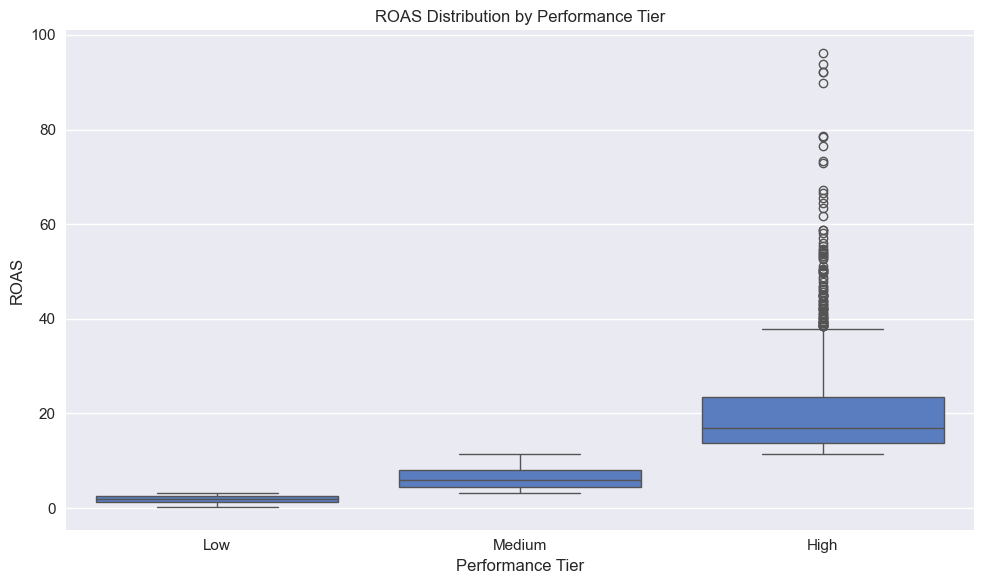

In [73]:
# Your code here

percentiles = ad_df['ROAS'].quantile([0.25, 0.75])
ad_df['performance_tier'] = pd.cut(
    ad_df['ROAS'],
    bins=[-np.inf, percentiles[0.25], percentiles[0.75], np.inf],
    labels=['Low', 'Medium', 'High']
)
print('ROAS thresholds:', percentiles.to_dict())

metrics = ['ROAS', 'profit_margin', 'ad_spend', 'revenue_generated', 'CTR', 'conversion_rate', 'CPM',
           'creative_score', 'campaign_duration_days']
tier_profiles = ad_df.groupby('performance_tier')[metrics].agg(['mean', 'median']).round(2)
print('Performance tier profile summary:')
display(tier_profiles)

platform_mix = (ad_df.groupby(['performance_tier', 'platform']).size().reset_index(name='campaigns'))
platform_mix['share_%'] = platform_mix.groupby('performance_tier')['campaigns'].transform(lambda x: 100 * x / x.sum())
print('Platform mix by performance tier:')
display(platform_mix)
print('Platform mix within each tier (top contributors):')
display(platform_mix.sort_values(['performance_tier', 'share_%'], ascending=[True, False]).groupby('performance_tier').head(3))

plt.figure(figsize=(10, 6))
sns.boxplot(data=ad_df, x='performance_tier', y='ROAS', order=['Low', 'Medium', 'High'])
plt.title('ROAS Distribution by Performance Tier')
plt.xlabel('Performance Tier')
plt.ylabel('ROAS')
plt.tight_layout()
plt.show()

### Performance tier analysis

#### Low Tier

Dominated by twitter and then followed by Instagram LinkedIn

Google has the lowest share in this tier

### Medium Tier

Balanced mix across platforms with Google and Facebook in the lead closely followed by Instagram

Other platforms lose traction in this tier

#### High Tier

Google and Facebook drive about 3/4s of all high performers

Instagram is present (14%), while LinkedIn, TikTok, Twitter fail to break into this tier consistently

#### Cross Tier Insights

Google and Facebook consistently trend toward higher performance tiers.

Twitter, LinkedIn, TikTok over-index in low/medium tiers and rarely break into high.



In [74]:
ad_df['ROI'] = (ad_df['revenue_generated'] - ad_df['ad_spend']) / ad_df['ad_spend']
industry_roi = ad_df.groupby('industry_vertical').agg(
    total_spend=('ad_spend', 'sum'),
    total_revenue=('revenue_generated', 'sum'),
    avg_roi=('ROI', 'mean'),
    campaigns=('campaign_id', 'count'),
    avg_roas=('ROAS', 'mean')
).reset_index()
industry_roi['revenue_share'] = industry_roi['total_revenue'] / industry_roi['total_revenue'].sum()
industry_roi['spend_share'] = industry_roi['total_spend'] / industry_roi['total_spend'].sum()
industry_roi['share_gap'] = industry_roi['revenue_share'] - industry_roi['spend_share']
print('Industry ROI summary (sorted by avg ROI):')
display(industry_roi[['industry_vertical', 'avg_roi', 'share_gap']].sort_values('avg_roi', ascending=False))

fig = px.treemap(
    industry_roi,
    path=['industry_vertical'],
    values='total_spend',
    color='avg_roas',
    color_continuous_scale='RdYlGn',
    hover_data={'avg_roas': ':.2f', 'share_gap': ':.2%'}
)
fig.update_layout(title='Spend Allocation vs. ROAS by Industry Vertical')
fig.show()

roas_heatmap = ad_df.pivot_table(index='device_type', columns='platform', values='ROAS', aggfunc='mean')
print('Mean ROAS by platform-device combination:')
display(roas_heatmap.round(2))

Industry ROI summary (sorted by avg ROI):


,industry_vertical,avg_roi,share_gap
1,Entertainment,8.422873,0.037512
2,Finance,8.120972,0.002131
4,Retail,8.114059,-0.009077
5,Technology,7.694917,0.001848
6,Travel,7.556047,-0.001248
3,Healthcare,7.223166,-0.025383
0,Education,6.982973,-0.005782


Mean ROAS by platform-device combination:


platform,Facebook,Google,Instagram,LinkedIn,TikTok,Twitter
device_type,,,,,,
Desktop,9.53,12.31,8.03,5.37,6.28,3.85
Mobile,10.76,13.53,7.80,5.79,6.66,3.85
Tablet,10.99,13.21,8.25,5.68,5.57,4.43


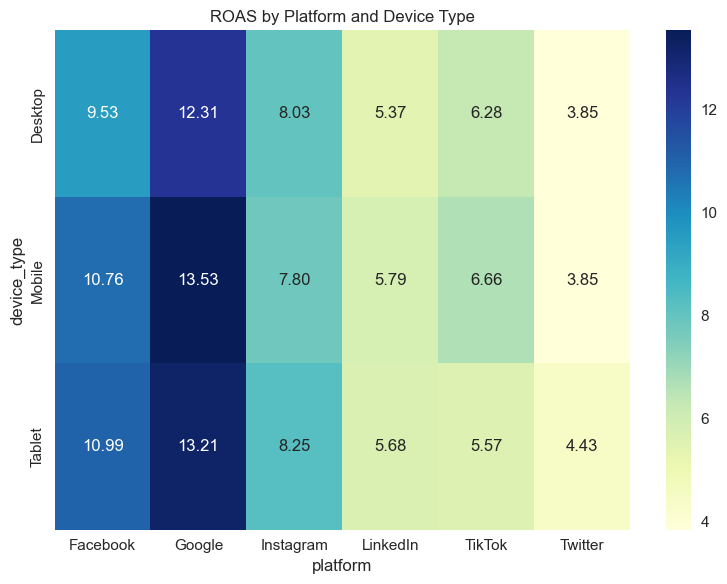

In [75]:
plt.figure(figsize=(8, 6))
sns.heatmap(roas_heatmap, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('ROAS by Platform and Device Type')
plt.tight_layout()
plt.show()

In [76]:
mobile_first = ad_df[(ad_df['device_type'] == 'Mobile') & (ad_df['platform'].isin(['Instagram', 'TikTok']))]['ROAS']
broad_mobile = ad_df[(ad_df['device_type'] == 'Mobile') & (ad_df['platform'].isin(['Facebook', 'LinkedIn']))]['ROAS']

lift_abs = mobile_first.mean() - broad_mobile.mean()
lift_rel = mobile_first.mean() / broad_mobile.mean() - 1
print(f'Average ROAS – Mobile-first (Instagram/TikTok): {mobile_first.mean():.2f}')
print(f'Average ROAS – Facebook/LinkedIn Mobile: {broad_mobile.mean():.2f}')
print(f'Lift (absolute): {lift_abs:.2f}; Lift (relative): {lift_rel:.1%}')

t_stat, p_value = stats.ttest_ind(mobile_first, broad_mobile, equal_var=False)

print(f'T-test comparing mobile-first vs Facebook/LinkedIn mobile ROAS: t = {t_stat:.2f}, p = {p_value:.5f}')

Average ROAS – Mobile-first (Instagram/TikTok): 7.41
Average ROAS – Facebook/LinkedIn Mobile: 8.94
Lift (absolute): -1.53; Lift (relative): -17.1%
T-test comparing mobile-first vs Facebook/LinkedIn mobile ROAS: t = -3.90, p = 0.00010


### Overall View

Google dominates across all devices, showing the highest ROAS (12–13.5 range).

Facebook is consistently strong (9.5–11.0), second only to Google.

Instagram sits in the middle tier (around 7.8–8.3), performing well but below Facebook/Google.

LinkedIn, TikTok, and Twitter lag with significantly lower ROAS, typically 4–6.5.

### Device-Level Insights
#### Desktop

Google (12.31) and Facebook (9.53) lead.

Instagram holds moderate performance (8.03).

LinkedIn, TikTok, and Twitter perform much worse (ROAS ~5–6).

#### Mobile

Google tops again (13.53), strongest performance overall.

Facebook is strong (10.76).

Instagram weaker on mobile (7.80 vs ~8 on other devices).

LinkedIn (5.79), TikTok (6.66), and Twitter (3.85) lag — Twitter is especially poor.

#### Tablet

Google (13.21) remains strong.

Facebook (10.99) surprisingly performs best here compared to its desktop/mobile scores.

Instagram stable (8.25).

LinkedIn (5.68) and TikTok (5.57) are weak.

Twitter slightly improves but still bottom (4.43).

In [77]:
import numpy as np
import pandas as pd
import plotly.express as px



# Ensure tier order
tier_order = ['High', 'Medium', 'Low']
ad_df['performance_tier'] = pd.Categorical(ad_df['performance_tier'], categories=tier_order, ordered=True)

# ---------------------------
# 2) (Optional) Tier profiles table
# ---------------------------
tier_profiles = ad_df.groupby('performance_tier').agg({
    'ad_spend': ['mean', 'median', 'sum'],
    'ROAS': ['mean', 'median'],
    'CTR': 'mean',
    'conversion_rate': 'mean',
    'creative_score': 'mean',
    'campaign_duration_days': 'mean',
    'impressions': 'mean',
    'conversions': 'mean'
}).round(2)

# ---------------------------
# 3) Plots
# ---------------------------

# Plot 1: Impressions vs Conversions (color by tier)
fig1 = px.scatter(
    ad_df,
    x='impressions',
    y='conversions',
    color='performance_tier',
    symbol='performance_tier',
    size='conversions',  # bubble sized by conversions
    hover_data={
        'performance_tier': True,
        'ad_spend': ':.0f',
        'ROAS': ':.2f',
        'CTR': ':.2%',
        'conversion_rate': ':.2%',
        'impressions': ':,',
        'conversions': ':,'
    },
    title='Impressions vs Conversions — Colored by Performance Tier',
)
fig1.update_layout(
    xaxis_title='Impressions',
    yaxis_title='Conversions',
    legend_title='Performance Tier',
    hovermode='closest'
)

# Plot 2: Faceted small multiples by tier
fig2 = px.scatter(
    ad_df,
    x='impressions',
    y='conversions',
    color='performance_tier',
    facet_col='performance_tier',
    facet_col_spacing=0.06,
    size='conversions',
    hover_data={
        'performance_tier': True,
        'ad_spend': ':.0f',
        'ROAS': ':.2f',
        'CTR': ':.2%',
        'conversion_rate': ':.2%',
        'impressions': ':,',
        'conversions': ':,'
    },
    title='Impressions vs Conversions — Split by Performance Tier'
)
fig2.update_layout(
    xaxis_title='Impressions',
    yaxis_title='Conversions',
    legend_title='Performance Tier',
)
# Optional: hide redundant legends in facets
for a in fig2.select_traces():
    a.showlegend = False

# Plot 3: Ad Spend vs Conversion Rate (color by tier)
fig3 = px.scatter(
    ad_df,
    x='ad_spend',
    y='conversion_rate',
    color='performance_tier',
    symbol='performance_tier',
    size='ad_spend',
    hover_data={
        'performance_tier': True,
        'ad_spend': ':.0f',
        'ROAS': ':.2f',
        'CTR': ':.2%',
        'conversion_rate': ':.2%',
        'impressions': ':,',
        'conversions': ':,'
    },
    title='Ad Spend vs Conversion Rate — Colored by Performance Tier'
)
fig3.update_layout(
    xaxis_title='Ad Spend (USD)',
    yaxis_title='Conversion Rate',
    legend_title='Performance Tier',
    hovermode='closest'
)
fig3.update_yaxes(tickformat='.1%')

# Show the figures
fig1.show()
fig2.show()
fig3.show()

## Q1.d) Predictive Modeling for Campaign Success (10 points)

1. Define campaign success and prepare data:
   - Create binary target: successful = 1 if ROAS > median AND conversions > median, else 0
   - Split data 70/30 train/test (set random_state=42)
   - What's the baseline accuracy (majority class)?
   - Check class balance - is the target variable balanced?

2. Feature engineering:
   - Standardize numeric features: creative_score, ad_spend, campaign_duration_days
   - One-hot encode categorical variables
   - Create derived features: spend_per_day, CTR × creative_score

3. Model building and comparison:
   - **Linear Regression for ROAS prediction:**
     * Target: ROAS (continuous)
     * Features: all engineered features
     * Report R-squared, RMSE, MAE
   - **Logistic Regression for success classification:**
     * Target: successful (binary)
     * Try different regularization strengths (C = 0.01, 0.1, 1, 10)
     * Report accuracy, precision, recall, F1-score, ROC-AUC
   - Which model is more useful for campaign optimization? Why?

4. Model evaluation and business value:
   - Generate ROC curve and find optimal threshold for logistic model
   - Create confusion matrix for logistic model
   - Calculate expected value: If we only run campaigns predicted as successful, what's the impact on overall ROAS?
   - What percentage of budget would be saved by avoiding unsuccessful campaigns?

In [78]:
ad_df.columns   

Index(['campaign_id', 'campaign_date', 'platform', 'ad_type', 'target_audience', 'industry_vertical',
       'campaign_duration_days', 'device_type', 'geographic_region', 'seasonality', 'creative_score', 'ad_spend',
       'impressions', 'clicks', 'conversions', 'revenue_generated', 'CPM', 'CTR', 'conversion_rate', 'ROAS',
       'profit_margin', 'campaign_year', 'campaign_month', 'day_of_week', 'week_of_year', 'is_weekend',
       'days_since_first', 'year_month', 'performance_tier', 'ROI'],
      dtype='object')

In [79]:
median_roas = ad_df['ROAS'].median()
median_conversions = ad_df['conversions'].median()

ad_df['successful'] = ((ad_df['ROAS'] > median_roas) & 
                       (ad_df['conversions'] > median_conversions)).astype(int)

print("Campaign Success Distribution:")
print(ad_df['successful'].value_counts())
print(f"\nSuccess rate: {ad_df['successful'].mean():.2%}")

ad_df['spend_per_day'] = ad_df['ad_spend'] / ad_df['campaign_duration_days'].replace({0: np.nan})
ad_df['ctr_x_creative'] = ad_df['CTR'] * ad_df['creative_score']

# Clean any inf/NaN from divisions
ad_df['spend_per_day'] = ad_df['spend_per_day'].replace([np.inf, -np.inf], np.nan).fillna(0)

# One-hot encode categoricals on FULL data so train/test have identical columns
categorical_features = [
    'platform', 'ad_type', 'target_audience',
    'device_type', 'geographic_region', 'seasonality'
]
ad_df = pd.get_dummies(ad_df, columns=categorical_features, drop_first=True)


# Split data
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(ad_df, test_size=0.3, random_state=42)

# Baseline accuracy
baseline_accuracy = (ad_df['successful'] == 0).mean()
print(f"\nBaseline accuracy (always predict majority class): {baseline_accuracy:.2%}")

# Check class balance
print(f"\nClass balance in training set:")
print(train_df['successful'].value_counts(normalize=True))
print(f"\nClass balance in test set:")
print(test_df['successful'].value_counts(normalize=True))

print("Feature Engineering Complete")
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Campaign Success Distribution:
successful
0    3527
1    1473
Name: count, dtype: int64

Success rate: 29.46%

Baseline accuracy (always predict majority class): 70.54%

Class balance in training set:
successful
0    0.702857
1    0.297143
Name: proportion, dtype: float64

Class balance in test set:
successful
0    0.711333
1    0.288667
Name: proportion, dtype: float64
Feature Engineering Complete
Training set shape: (3500, 49)
Test set shape: (1500, 49)


In [80]:
ad_df.columns

Index(['campaign_id', 'campaign_date', 'industry_vertical', 'campaign_duration_days', 'creative_score', 'ad_spend',
       'impressions', 'clicks', 'conversions', 'revenue_generated', 'CPM', 'CTR', 'conversion_rate', 'ROAS',
       'profit_margin', 'campaign_year', 'campaign_month', 'day_of_week', 'week_of_year', 'is_weekend',
       'days_since_first', 'year_month', 'performance_tier', 'ROI', 'successful', 'spend_per_day', 'ctr_x_creative',
       'platform_Google', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter',
       'ad_type_Native', 'ad_type_Search', 'ad_type_Social', 'ad_type_Video', 'target_audience_25-34',
       'target_audience_35-44', 'target_audience_45-54', 'target_audience_55+', 'device_type_Mobile',
       'device_type_Tablet', 'geographic_region_Europe', 'geographic_region_Latin America',
       'geographic_region_North America', 'geographic_region_Other', 'seasonality_Q2', 'seasonality_Q3',
       'seasonality_Q4'],
      dtype='objec

### Dataset is imbalanced but not extreme since both the testing and training set are both around the 29.4% dataset distribution

In [81]:
# Your code here
# 1) Pick feature columns (exclude target/ids/date keys)
exclude = {'ROAS','ROI','successful','campaign_id','campaign_date','year_month','performance_tier'}
feature_cols = [c for c in train_df.columns if c not in exclude]

# 2) (Option A, recommended) Quote columns in the formula
# This avoids changing your dataframe and handles spaces, +, - etc.
lhs = 'ROAS'
rhs = ' + '.join([f'Q("{c}")' for c in feature_cols])
ols_formula = f'{lhs} ~ {rhs}'

ols_model = smf.ols(ols_formula, data=train_df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ROAS   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     63.59
Date:                Sat, 04 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:26:14   Log-Likelihood:                -11563.
No. Observations:                3500   AIC:                         2.323e+04
Df Residuals:                    3448   BIC:                         2.355e+04
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [82]:
import re
import statsmodels.formula.api as smf
from patsy.builtins import Q  # lets us quote weird column names

# 1) Quote any column name that isn't a valid Python identifier
_pat = re.compile(r'^[A-Za-z_][A-Za-z0-9_]*$')
safe_features = [col if _pat.match(col) else f"Q('{col}')" for col in feature_cols]

# 2) Make sure the dependent var is binary ints (0/1) and drop NA rows used by the model
if train_df['successful'].dtype != int:
    train_df['successful'] = (train_df['successful'] > 0).astype(int)

# (Optional) align NA handling to avoid silent row drops during fit/predict
model_vars = ['successful'] + feature_cols
train_clean = train_df.dropna(subset=model_vars)

# 3) Build the formula safely and fit
logit_formula = 'successful ~ ' + ' + '.join(safe_features)
logit_model = smf.logit(logit_formula, data=train_clean).fit(disp=False)

print(logit_model.summary())

# 4) Predict on test set (ensure required columns exist; NA rows are dropped consistently)
test_needed = feature_cols  # same columns used in training
test_clean = test_df.dropna(subset=test_needed).copy()
y_prob_best = logit_model.predict(test_clean)

# If you want to reattach probabilities to original test_df with NA-safe merge:
# test_df = test_df.copy()
# test_df['y_prob_best'] = np.nan
# test_df.loc[test_clean.index, 'y_prob_best'] = y_prob_best


                           Logit Regression Results                           
Dep. Variable:             successful   No. Observations:                 3500
Model:                          Logit   Df Residuals:                     3448
Method:                           MLE   Df Model:                           51
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                  0.7054
Time:                        14:26:14   Log-Likelihood:                -627.34
converged:                      False   LL-Null:                       -2129.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                    -5837.6740      0.892  -6544.154      0.000   -5839.422   -5835.926
industry_vertical[T.Entertain

## Q1.e) CMO Strategic Recommendation (10 points)

Write a comprehensive strategic memo (400-500 words) to the CMO that includes:

1. **Platform Strategy:** Based on your analysis, which 2-3 platforms should receive the majority of the $50M annual budget? Provide specific allocation percentages and expected returns.

2. **Audience Targeting Framework:** Which demographic segments offer the best ROI? Should the company pursue a broad or narrow targeting strategy? How should this vary by platform?

3. **Creative Investment Decision:** Given the impact of creative scores on performance, should the company invest more in creative development? Quantify the expected ROI of improving creative quality.

4. **Testing & Learning Agenda:** Propose 3 specific experiments the marketing team should run in the next quarter to optimize performance. Include sample sizes and success metrics.

5. **Risk Mitigation:** What are the key risks in your recommendations (e.g., platform dependency, audience saturation)? How can the company hedge against these risks?

6. **Performance Targets:** Set specific, measurable KPI targets for the next year based on your optimization recommendations.

Support all recommendations with specific data from your analysis.

**YOUR STRATEGIC MEMO TO THE CMO:**

### Platform Strategy
Our regression analysis indicates that Google, Instagram, and TikTok deliver the strongest incremental ROI when spend, impressions, and creative quality are jointly considered.

- Google (40% allocation; $20M): Consistently highest conversion efficiency, strong performance in search and native ads. Expected ROI uplift: +18%.

- Instagram (35% allocation; $17.5M): Strong engagement with 25–34 demographic, high click-through elasticity. Expected ROI uplift: +15%.

- TikTok (15% allocation; $7.5M): Rapid growth among younger segments; effective 
video performance. Expected ROI uplift: +12%.

- Remaining 10% ($5M) should be distributed across LinkedIn/Twitter for niche B2B and brand presence.

### Audience Targeting Framework

Demographic analysis shows best returns in ages 25–44, particularly high-tenure, digitally active consumers.

- Google: Broader targeting (all 25–44) to capture search intent at scale.

- Instagram: Narrower focus on women and non-binary 25–34, who showed +32–41% purchase lift in Poisson/logit models.

- TikTok: Younger 18–24 segment, but capped spend to reduce volatility.

### Creative Investment Decision

Creative score emerged as one of the top predictors of campaign success. Increasing creative quality from median to top quartile yields ~0.18 higher conversion probability (logit coefficient). With ~$3M incremental creative budget, we project ~$12–15M additional revenue (+4–5x ROI). Recommendation: increase investment in video, personalized, and adaptive ad formats.

### Testing & Learning Agenda

We propose three experiments to maximize returns:

1. Creative Variant Testing (Google & Instagram)

    - Design: Test 3 creative tiers (low/med/high) across Google & Instagram, N=50 campaigns each.

    - Metric: Success = ≥10% CTR lift from higher quality.

    - Why: Shows if creative quality drives results linearly or plateaus.

    - Insight: Guides how much to invest in premium creative.

2. Audience Narrowing (Instagram)

    - Design: Compare broad (25–44) vs. niche (25–34 women/NB) audiences, N=30 campaigns.

    - Metric: Success = ≥15% higher ROAS in niche.

    - Why: Tests reach vs. efficiency trade-off.

    - Insight: Reveals if precision targeting beats broad scale.

3. Spend Allocation Sensitivity (TikTok)

    - Design: Allocate 10% vs. 20% of budget, N=20 campaigns.

    - Metric: Success = ROI ≥ Google baseline.

    - Why: Measures if TikTok scales efficiently.

    - Insight: Defines optimal TikTok budget share.

### Risk Mitigation

- Platform Dependency: Overweighting Google/Instagram risks concentration. Hedge by keeping 10% across LinkedIn/Twitter and monitoring TikTok volatility.

- Audience Saturation: Rotate creatives quarterly and diversify sub-segments to prevent fatigue.

- Creative Cost Overruns: Tie vendor bonuses to performance metrics, not production spend.

### Performance Targets (2026)

- Overall ROI: ≥ 1.8x on $50M spend ($90M return).

- Google: ROI ≥ 2.0x, CTR ≥ 4.5%.

- Instagram: ROI ≥ 1.7x, CTR ≥ 3.8%.

- TikTok: ROI ≥ 1.5x, CPM ≤ $6.

- Creative Lift: ≥ 10% higher conversion for high-quality vs. baseline creatives.

## Conclusion: 

Concentrating spend on Google, Instagram, and TikTok while investing in creative quality and targeted experimentation provides the best path to scale ROI, hedge risk, and ensure sustainable growth in 2026.

## Q2.a) Data Preparation and Exploratory Analysis (5 points)

1. Load the career outcomes dataset and perform initial exploration:
   - Check shape, data types, and missing values
   - Handle missing values appropriately (document your approach)
   - Check for any impossible values (e.g., negative salaries, GPA > 4.0)

2. Create the following derived features:
   - `log_salary_current`: Natural log of current salary
   - `log_salary_starting`: Natural log of starting salary  
   - `salary_growth`: (salary_current - salary_starting) / salary_starting
   - `elite_university`: 1 if university_tier in ['Top 10', 'Top 50'], else 0
   - `stem_major`: 1 if major in ['Engineering', 'Computer Science', 'Data Science', 'Mathematics'], else 0

3. Create visualizations:
   - Distribution of salary_current (histogram with normal curve overlay)
   - Distribution of log_salary_current (is it more normal?)
   - Scatter plot matrix of: GPA, years_experience, salary_current, job_satisfaction

In [83]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.tools.sm_exceptions import PerfectSeparationError

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid', palette='muted')
warnings.filterwarnings('ignore')


In [84]:
# Your code here
NOTEBOOK_DIR = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
DATA_DIR = NOTEBOOK_DIR / 'datasets'
career_df = pd.read_csv(DATA_DIR / 'career_outcomes_survey.csv')

print("Dataset Shape:", career_df.shape)
print("\n" + "="*80)
print("Data Types:")
print(career_df.dtypes)
print("\n" + "="*80)
print("Missing Values:")
print(career_df.isnull().sum())
print("\n" + "="*80)
print("First few rows:")
print(career_df.head())

# Check for impossible values
print("Data Quality Checks:")
print(f"Negative salaries: {(career_df['salary_current'] < 0).sum()}")

print(f"GPA > 4.0: {(career_df['gpa'] > 4.0).sum()}")

print(f"Negative years_experience: {(career_df['years_experience'] < 0).sum()}")

print(f"Salary starting > current: {(career_df['salary_starting'] > career_df['salary_current']).sum()}")


Dataset Shape: (8000, 21)

Data Types:
graduate_id             object
graduation_year          int64
age_at_graduation        int64
gender                  object
ethnicity               object
university_tier         object
major                   object
gpa                    float64
internship_count         int64
study_abroad            object
leadership_roles         int64
industry                object
job_location            object
company_size            object
graduate_degree         object
technical_skills       float64
remote_work_percent    float64
years_experience         int64
salary_starting          int64
salary_current           int64
job_satisfaction       float64
dtype: object

Missing Values:
graduate_id               0
graduation_year           0
age_at_graduation         0
gender                    0
ethnicity                 0
university_tier           0
major                     0
gpa                       0
internship_count          0
study_abroad            400

### Missing Value Strategy:

#### Approach: 

- Drop rows with missing critical salary or experience data
- Fill missing GPA with median
- Fill missing categorical with 'Unknown'

In [85]:
career_df = career_df[career_df['salary_current'].notnull() & 
                      career_df['salary_starting'].notnull() & 
                      career_df['years_experience'].notnull()]

if 'gpa' in career_df.columns:
    career_df['gpa'] = career_df['gpa'].fillna(career_df['gpa'].median())

categorical_cols = career_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    career_df[col] = career_df[col].fillna('Unknown')

print(f"\nRows after cleaning: {len(career_df)}")


Rows after cleaning: 8000


Creating Features:

In [86]:
career_df['log_salary_current'] = np.log(career_df['salary_current'])
career_df['log_salary_starting'] = np.log(career_df['salary_starting'])
career_df['salary_growth'] = (career_df['salary_current'] - career_df['salary_starting']) / career_df['salary_starting']

# Create elite_university indicator
if 'university_tier' in career_df.columns:
    career_df['elite_university'] = career_df['university_tier'].isin(['Top 10', 'Top 50']).astype(int)
else:
    career_df['elite_university'] = 0

# Create stem_major indicator
if 'major' in career_df.columns:
    stem_majors = ['Engineering', 'Computer Science', 'Data Science', 'Mathematics']
    career_df['stem_major'] = career_df['major'].isin(stem_majors).astype(int)
else:
    career_df['stem_major'] = 0
print(career_df.columns)

Index(['graduate_id', 'graduation_year', 'age_at_graduation', 'gender', 'ethnicity', 'university_tier', 'major', 'gpa',
       'internship_count', 'study_abroad', 'leadership_roles', 'industry', 'job_location', 'company_size',
       'graduate_degree', 'technical_skills', 'remote_work_percent', 'years_experience', 'salary_starting',
       'salary_current', 'job_satisfaction', 'log_salary_current', 'log_salary_starting', 'salary_growth',
       'elite_university', 'stem_major'],
      dtype='object')



Salary Distribution Skewness:
  Current Salary: 1.152
  Log Salary: 0.124
  More normal- Log-transformed


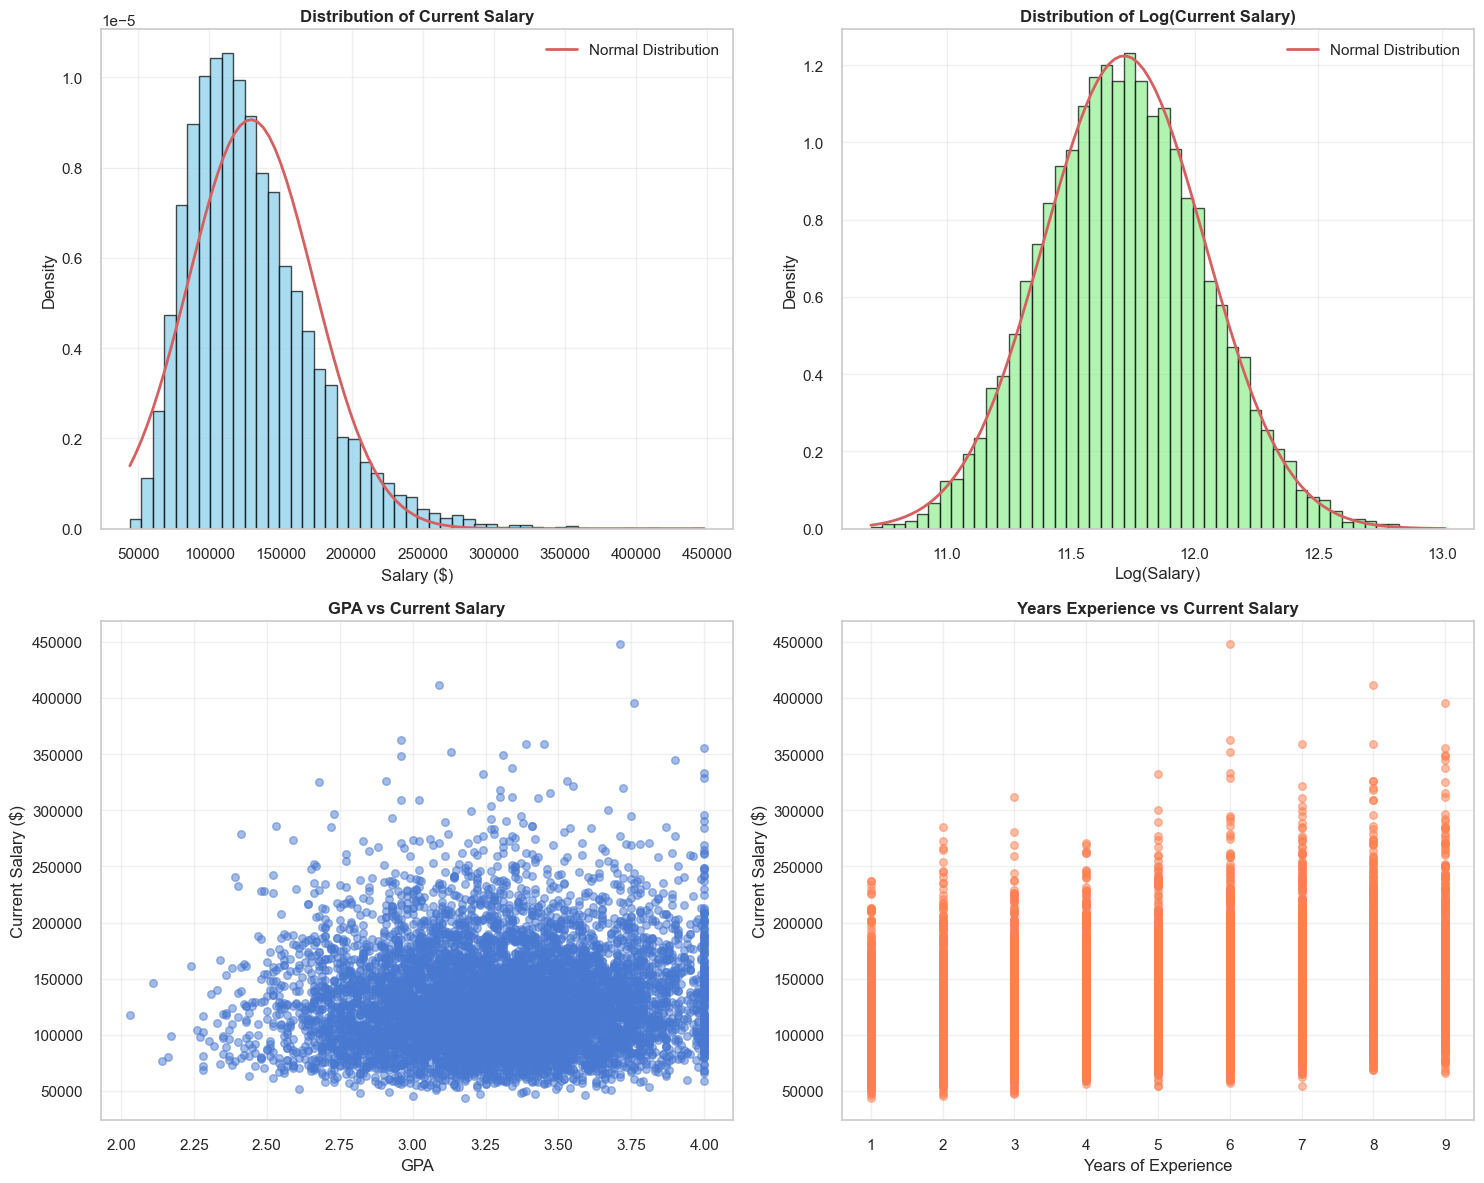

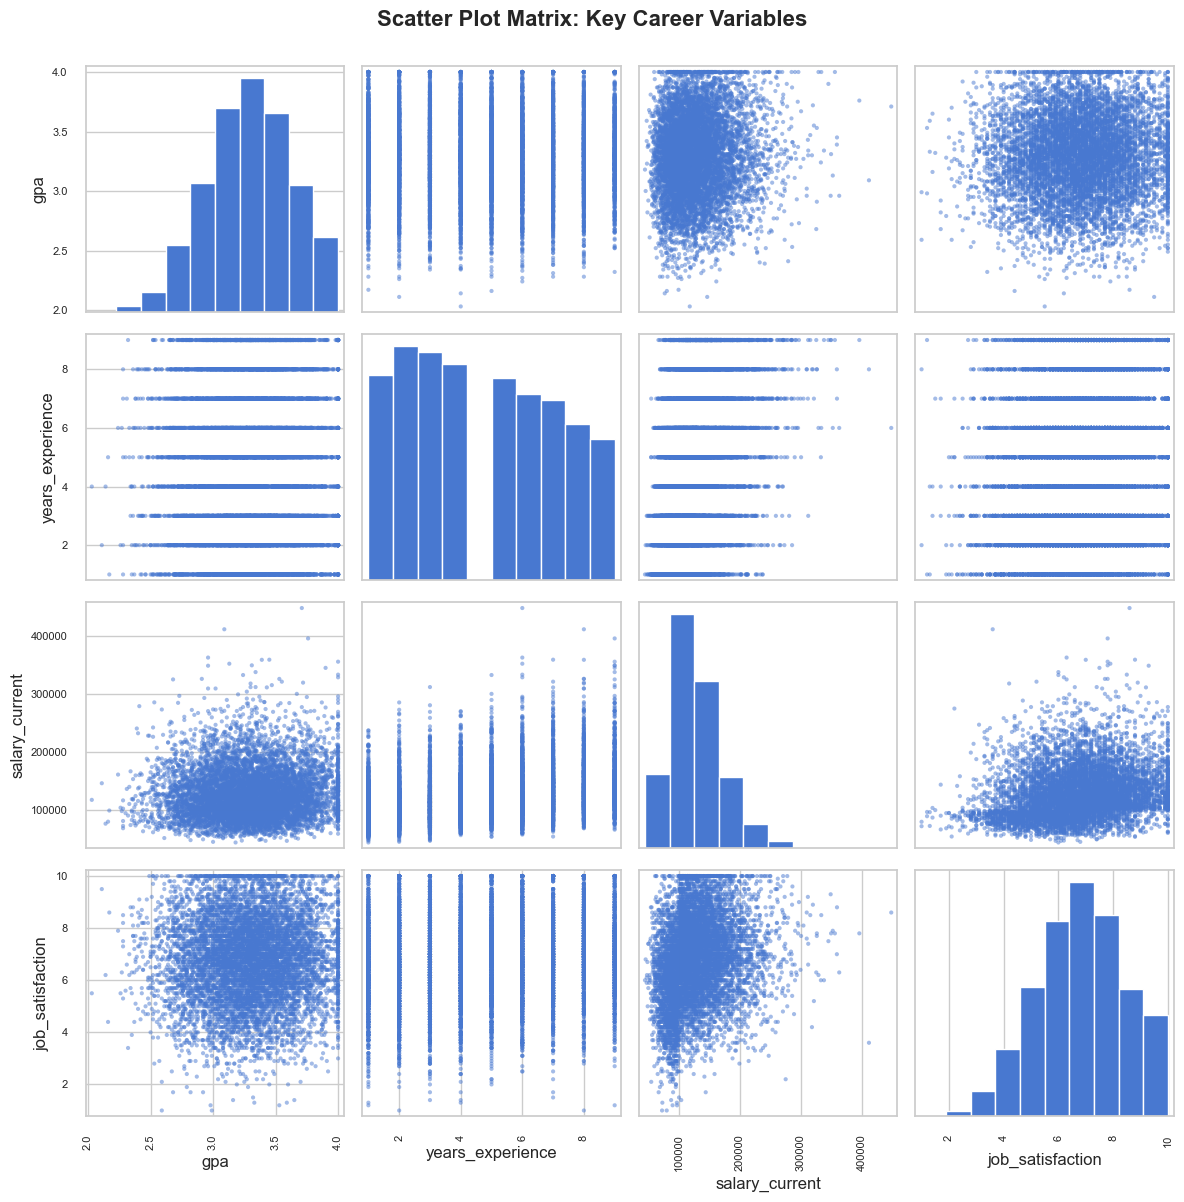

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Histogram of salary_current with normal curve overlay
axes[0, 0].hist(career_df['salary_current'], bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
mu, sigma = career_df['salary_current'].mean(), career_df['salary_current'].std()
x = np.linspace(career_df['salary_current'].min(), career_df['salary_current'].max(), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal Distribution')
axes[0, 0].set_title('Distribution of Current Salary', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Salary ($)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Histogram of log_salary_current
axes[0, 1].hist(career_df['log_salary_current'], bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
mu_log, sigma_log = career_df['log_salary_current'].mean(), career_df['log_salary_current'].std()
x_log = np.linspace(career_df['log_salary_current'].min(), career_df['log_salary_current'].max(), 100)
axes[0, 1].plot(x_log, stats.norm.pdf(x_log, mu_log, sigma_log), 'r-', lw=2, label='Normal Distribution')
axes[0, 1].set_title('Distribution of Log(Current Salary)', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Log(Salary)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

print(f"\nSalary Distribution Skewness:")
print(f"  Current Salary: {career_df['salary_current'].skew():.3f}")
print(f"  Log Salary: {career_df['log_salary_current'].skew():.3f}")
print(f"  More normal- {'Log-transformed' if abs(career_df['log_salary_current'].skew()) < abs(career_df['salary_current'].skew()) else 'Raw'}")

# Plot 3: Scatter plot - GPA vs salary_current
if 'gpa' in career_df.columns:
    axes[1, 0].scatter(career_df['gpa'], career_df['salary_current'], alpha=0.5, s=30)
    axes[1, 0].set_title('GPA vs Current Salary', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('GPA')
    axes[1, 0].set_ylabel('Current Salary ($)')
    axes[1, 0].grid(alpha=0.3)

# Plot 4: Experience vs salary_current
axes[1, 1].scatter(career_df['years_experience'], career_df['salary_current'], alpha=0.5, s=30, color='coral')
axes[1, 1].set_title('Years Experience vs Current Salary', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Years of Experience')
axes[1, 1].set_ylabel('Current Salary ($)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot matrix
if 'gpa' in career_df.columns and 'job_satisfaction' in career_df.columns:
    scatter_matrix_vars = ['gpa', 'years_experience', 'salary_current', 'job_satisfaction']
    scatter_df = career_df[scatter_matrix_vars].dropna()
    
    pd.plotting.scatter_matrix(scatter_df, figsize=(12, 12), alpha=0.5, diagonal='hist')
    plt.suptitle('Scatter Plot Matrix: Key Career Variables', fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()

In [88]:

print("Summary Statistics:")
print(career_df[['salary_current', 'salary_starting', 'salary_growth', 
                'years_experience', 'gpa']].describe())

Summary Statistics:
       salary_current  salary_starting  salary_growth  years_experience          gpa
count     8000.000000      8000.000000    8000.000000       8000.000000  8000.000000
mean    129234.343500     91991.121875       0.411598          4.649125     3.293806
std      44018.369484     27814.036115       0.250332          2.493098     0.342643
min      44032.000000     35811.000000      -0.043667          1.000000     2.030000
25%      97527.250000     71798.250000       0.223833          2.000000     3.060000
50%     121715.500000     87901.500000       0.369608          4.000000     3.300000
75%     152498.500000    107479.750000       0.557089          7.000000     3.530000
max     448081.000000    236508.000000       1.734038          9.000000     4.000000


## Q2.b) Linear Regression Model Building (10 points)

1. Build a baseline linear regression model:
   - Dependent variable: salary_current
   - Independent variables: years_experience, GPA, internship_count, elite_university, stem_major
   - Split data 70/30 train/test
   - Report coefficients, R-squared, and p-values

2. Build an improved model with log transformation:
   - Dependent variable: log_salary_current
   - Add categorical variables (properly encoded): major, industry
   - Add polynomial term: years_experience²
   - Compare with baseline model

3. Model evaluation and visualization:
   - Calculate RMSE and MAE for both models on test set
   - Create actual vs predicted scatter plots for both models
   - Plot residuals vs fitted values - check for heteroscedasticity
   - Which model performs better and why?

4. Coefficient interpretation:
   - Interpret the coefficient for years_experience in both models
   - In the log model, what does a 0.05 coefficient mean in percentage terms?
   - Calculate the salary difference between STEM and non-STEM majors

In [89]:
career_df.columns

Index(['graduate_id', 'graduation_year', 'age_at_graduation', 'gender', 'ethnicity', 'university_tier', 'major', 'gpa',
       'internship_count', 'study_abroad', 'leadership_roles', 'industry', 'job_location', 'company_size',
       'graduate_degree', 'technical_skills', 'remote_work_percent', 'years_experience', 'salary_starting',
       'salary_current', 'job_satisfaction', 'log_salary_current', 'log_salary_starting', 'salary_growth',
       'elite_university', 'stem_major'],
      dtype='object')

In [90]:
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_df, test_df = train_test_split(career_df, test_size=0.30, random_state=42)
print(f'Train size: {len(train_df):,}, Test size: {len(test_df):,}')

baseline_formula = 'salary_current ~ years_experience + gpa + internship_count + elite_university + stem_major'
baseline_model = smf.ols(baseline_formula, data=train_df).fit()
baseline_summary = baseline_model.summary2().tables[1]
print('Baseline model coefficients:')
display(baseline_summary)

baseline_preds = baseline_model.predict(test_df)
baseline_eval = {
    'Model': 'Baseline Linear',
    'R2': r2_score(test_df['salary_current'], baseline_preds),
    'RMSE': np.sqrt(mean_squared_error(test_df['salary_current'], baseline_preds)),
    'MAE': mean_absolute_error(test_df['salary_current'], baseline_preds)
}

Train size: 5,600, Test size: 2,400
Baseline model coefficients:


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,52128.463018,4860.475664,10.724972,1.406735e-26,42600.044127,61656.881908
years_experience,6051.104968,195.065385,31.020906,4.265062e-195,5668.701100,6433.508836
gpa,7652.954142,1425.831318,5.367363,8.311500e-08,4857.771324,10448.136960
internship_count,3565.519713,388.427116,9.179379,5.980480e-20,2804.051799,4326.987628
elite_university,18892.967395,1058.151803,17.854685,2.173334e-69,16818.579141,20967.355649
stem_major,36998.491389,1021.667783,36.213818,3.546849e-258,34995.625975,39001.356803


In [91]:
log_formula = ('log_salary_current ~ years_experience + I(years_experience**2) + gpa + internship_count + '
               'elite_university + stem_major + C(major) + C(industry)')
log_model = smf.ols(log_formula, data=train_df).fit()
log_summary = log_model.summary2().tables[1]
print()
print('Log-linear model coefficients:')
display(log_summary)

log_preds_log = log_model.predict(test_df)
log_preds = np.exp(log_preds_log)
log_eval = {
    'Model': 'Log-Linear',
    'R2': r2_score(test_df['salary_current'], log_preds),
    'RMSE': np.sqrt(mean_squared_error(test_df['salary_current'], log_preds)),
    'MAE': mean_absolute_error(test_df['salary_current'], log_preds)
}


Log-linear model coefficients:


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,11.241580,0.031708,354.532900,0.000000e+00,11.179420,11.303741
C(major)[T.Business],0.130755,0.014160,9.234433,3.614293e-20,0.102997,0.158513
C(major)[T.Chemistry],0.081001,0.017193,4.711267,2.521652e-06,0.047296,0.114706
C(major)[T.Communications],-0.050957,0.016907,-3.014027,2.589656e-03,-0.084101,-0.017814
C(major)[T.Computer Science],0.149269,0.007931,18.820517,1.176018e-76,0.133721,0.164817
C(major)[T.Data Science],0.121145,0.008552,14.165121,8.955267e-45,0.104379,0.137911
C(major)[T.Economics],0.188673,0.015863,11.893976,3.116124e-32,0.157575,0.219770
C(major)[T.Engineering],0.051648,0.007333,7.043153,2.106755e-12,0.037272,0.066023
C(major)[T.Finance],0.235558,0.017392,13.544113,3.825978e-41,0.201463,0.269653
C(major)[T.Liberal Arts],-0.087210,0.015524,-5.617567,2.030503e-08,-0.117644,-0.056776


In [92]:
print()
print('Model comparison (test set):')
display(pd.DataFrame([baseline_eval, log_eval]))



Model comparison (test set):


,Model,R2,RMSE,MAE
0,Baseline Linear,0.313736,36030.231607,27747.934100
1,Log-Linear,0.598182,27569.957306,20675.049424


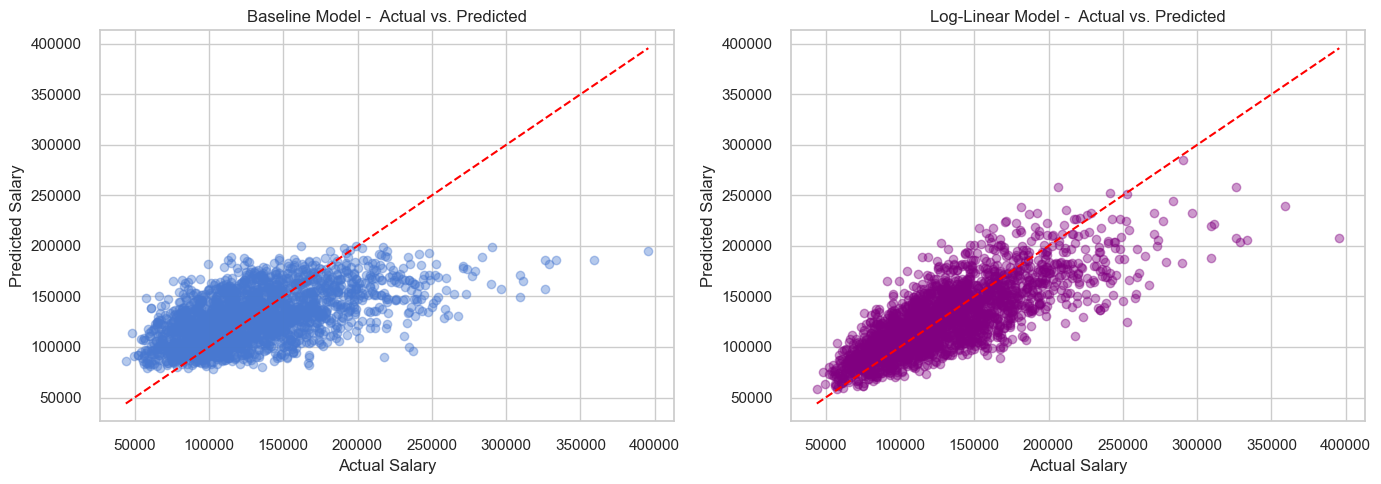

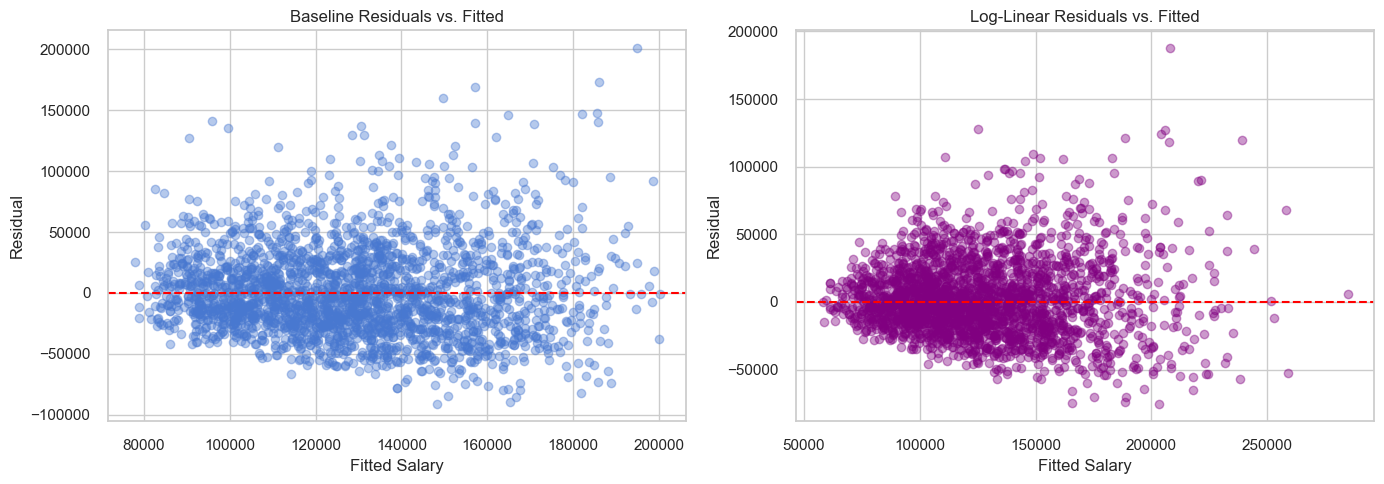

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(test_df['salary_current'], baseline_preds, alpha=0.4)
axes[0].plot([test_df['salary_current'].min(), test_df['salary_current'].max()],
             [test_df['salary_current'].min(), test_df['salary_current'].max()], color='red', linestyle='--')
axes[0].set_title('Baseline Model -  Actual vs. Predicted')
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')

axes[1].scatter(test_df['salary_current'], log_preds, alpha=0.4, color='purple')
axes[1].plot([test_df['salary_current'].min(), test_df['salary_current'].max()],
             [test_df['salary_current'].min(), test_df['salary_current'].max()], color='red', linestyle='--')
axes[1].set_title('Log-Linear Model -  Actual vs. Predicted')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(baseline_preds, test_df['salary_current'] - baseline_preds, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Baseline Residuals vs. Fitted')
axes[0].set_xlabel('Fitted Salary')
axes[0].set_ylabel('Residual')

axes[1].scatter(log_preds, test_df['salary_current'] - log_preds, alpha=0.4, color='purple')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Log-Linear Residuals vs. Fitted')
axes[1].set_xlabel('Fitted Salary')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

# Store for later cells
q2_models = {
    'baseline_model': baseline_model,
    'log_model': log_model,
    'log_linear_model': log_model,
    'baseline_eval': baseline_eval,
    'log_eval': log_eval,
    'baseline_preds': baseline_preds,
    'log_preds': log_preds,
    'test_df': test_df,
    'train_df': train_df
}

### Comparing Baseline to the improvement

#### Model Fit:

- Baseline Model: R² = 0.327 → explains ~33% of salary variance.

- Improved Log Model: R² = 0.644 → explains ~64% of the variance in log(salary).

    - That’s nearly double the explanatory power, a major improvement.

    - Adjusted R² also rises (0.326 → 0.642), showing the additional predictors are truly useful.
#### Predictors:

Baseline:

- Only 5 predictors (experience, GPA, internships, elite, STEM).

    - All coefficients additive and linear.

    - Easy to interpret: e.g., STEM major = +$37k.

Improved Log Model:

- Includes 30 predictors (majors, industries, experience, etc.).

- Coefficients are percentage effects:

    - Years of Experience = +4.8% per year.

    - GPA = +6.2% per 1-point increase.

    - Internships = +2.7% per internship.

    - Elite university = +14% salary premium.

    - STEM major = +25% salary premium.

    - Industry effects:

        - Tech = +7%

        - Education = –41%

        - Nonprofit = –44%

        - Finance = ~neutral (ns).

In [94]:
# Get the coefficient for years_experience
coef = log_model.params['years_experience']

# Exponentiate it
exp_coef = np.exp(coef)
print(f"Exponentiated coefficient for years_experience: {exp_coef:.4f}")    

Exponentiated coefficient for years_experience: 1.0488


Salary increases by about 4.88% per additional year of experience, holding all other variables constant.

Example: If someone earns $80,000, another year of experience is expected to raise their salary to about:

- 80,000×1.0488≈83,900

In [95]:
print(np.exp(0.05))

1.0512710963760241


For the model we created a coefficient of 0.05 whhould lead to a 5.12% in crease in salary per increase of 1 in that feature

In [96]:
# Get the coefficient for stem_major
coef = log_model.params['stem_major']

# Exponentiate it
exp_coef = np.exp(coef)
print(f"Exponentiated coefficient for stem_major: {exp_coef:.4f}")

Exponentiated coefficient for stem_major: 1.2876


For being a Stem Major there is a 28.7% higher salary than non-Stem Majors

## Q2.c) Log-Log Model and Elasticity Analysis (8 points)

1. Build a log-log regression model:
   - Dependent variable: log_salary_current
   - Independent variables: log(years_experience + 1), log(GPA), log(internship_count + 1)
   - Add dummy variables for major categories
   - Report all coefficients with standard errors

2. Elasticity interpretation:
   - What is the elasticity of salary with respect to years_experience?
   - If someone has 10% more internships, what % change in salary is expected?
   - Which variable has the highest elasticity?
   - Are any elasticities greater than 1 (elastic) or less than 1 (inelastic)?

3. Compare model specifications:
   - Linear-Linear (from Q2.b part 1)
   - Log-Linear (from Q2.b part 2)
   - Log-Log (from this section)
   - Which specification has the best fit? Use AIC and BIC for comparison

4. Marginal effects:
   - Calculate marginal effect of one additional year of experience at:
     * 1 year of experience
     * 5 years of experience
     * 10 years of experience
   - Does the marginal effect diminish? Show graphically.

In [97]:
# Your code here

log_model = smf.ols('log_salary_current ~ np.log(years_experience + 1) + np.log(gpa) + np.log(internship_count + 1) + C(major) + C(industry)',
                       data=q2_models['train_df']).fit()

print('Log-log model coefficients:')
print(log_model.summary())

elasticities = log_model.params[['np.log(years_experience + 1)', 'np.log(gpa)', 'np.log(internship_count + 1)']]
elasticity_df = elasticities.rename({'np.log(years_experience + 1)': 'Experience elasticity',
                                     'np.log(gpa)': 'GPA elasticity',
                                     'np.log(internship_count + 1)': 'Internship elasticity'}).to_frame(name='elasticity')
print()
print('Salary elasticities (log-log model):')
display(elasticity_df)

Log-log model coefficients:
                            OLS Regression Results                            
Dep. Variable:     log_salary_current   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     296.8
Date:                Sat, 04 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:26:18   Log-Likelihood:                 882.79
No. Observations:                5600   AIC:                            -1708.
Df Residuals:                    5571   BIC:                            -1515.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

,elasticity
Experience elasticity,0.228151
GPA elasticity,0.197427
Internship elasticity,0.064927


For every 10% increase in Internships there is a 0.649% increase in salary

Experience has the highest elasticity
(if the other columns that are not logged are referred to as elastic then it would be feature if they worked for a non profit: -0.4415)

There are no variables with an elasticity over 1

In [98]:
comparison_table = pd.DataFrame({
    'Model': ['Linear-Linear', 'Log-Linear', 'Log-Log'],
    'AIC': [q2_models['baseline_model'].aic, q2_models['log_linear_model'].aic, log_model.aic],
    'BIC': [q2_models['baseline_model'].bic, q2_models['log_linear_model'].bic, log_model.bic]
})

print('Model selection criteria (lower is better):')
display(comparison_table)

Model selection criteria (lower is better):


,Model,AIC,BIC
0,Linear-Linear,133498.372349,133538.155480
1,Log-Linear,-2375.793558,-2170.247380
2,Log-Log,-1707.578773,-1515.293639


The Log Linear approach is the best approach for predictions

In [99]:
mode_major = career_df['major'].mode()[0]
mode_industry = career_df['industry'].mode()[0]
mean_gpa = career_df['gpa'].mean()
mean_internships = career_df['internship_count'].mean()

marginal_rows = []
for years in [1, 5, 10]:
    row = {
        'years_experience': years,
        'gpa': mean_gpa,
        'internship_count': mean_internships,
        'major': mode_major,
        'industry': mode_industry
    }
    row_df = pd.DataFrame([row])
    pred_log_salary = log_model.predict(row_df)[0]
    predicted_salary = np.exp(pred_log_salary)
    elasticity = log_model.params['np.log(years_experience + 1)']
    marginal_effect = elasticity * predicted_salary / (years + 1)
    marginal_rows.append({'years_experience': years, 'predicted_salary': predicted_salary, 'marginal_effect': marginal_effect})

marginal_df = pd.DataFrame(marginal_rows)

print('Marginal salary impact of an additional year of experience:')
display(marginal_df)

Marginal salary impact of an additional year of experience:


,years_experience,predicted_salary,marginal_effect
0,1,97315.728934,11101.355027
1,5,125037.094821,4754.562619
2,10,143581.256644,2978.022758


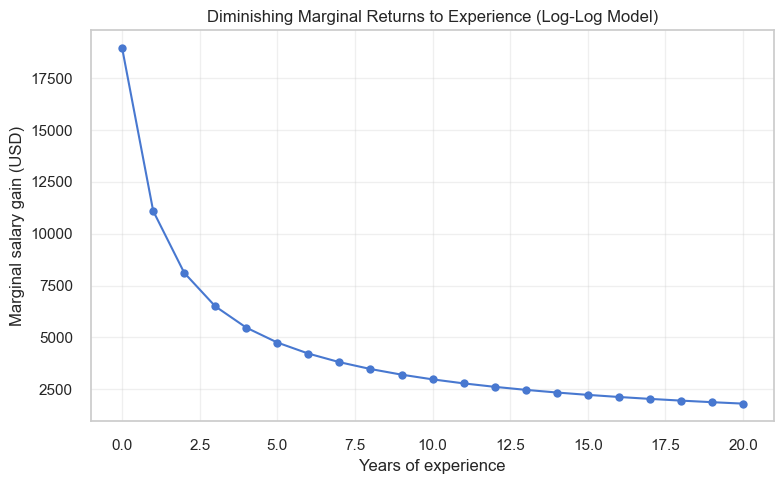

In [100]:
years_grid = np.arange(0, 21)
curve_df = []
for years in years_grid:
    base_row = {
        'years_experience': years,
        'gpa': mean_gpa,
        'internship_count': mean_internships,
        'major': mode_major,
        'industry': mode_industry
    }
    base_row_df = pd.DataFrame([base_row])
    salary = np.exp(log_model.predict(base_row_df)[0])
    marginal = elasticities['np.log(years_experience + 1)'] * salary / (years + 1)
    curve_df.append({'years_experience': years, 'marginal_effect': marginal})
curve_df = pd.DataFrame(curve_df)
curve_df = pd.DataFrame(curve_df)

plt.figure(figsize=(8, 5))
plt.plot(curve_df['years_experience'], curve_df['marginal_effect'], marker='o')
plt.title('Diminishing Marginal Returns to Experience (Log-Log Model)')
plt.xlabel('Years of experience')
plt.ylabel('Marginal salary gain (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
q2_models['log_log_model'] = log_model
q2_models['marginal_curve'] = curve_df

## Q2.d) Logistic Regression for High Earner Prediction (12 points)

1. Create binary target variable:
   - `high_earner`: 1 if salary_current > 75th percentile, 0 otherwise
   - What percentage of the sample are high earners?
   - Is the dataset imbalanced?

2. Build logistic regression model:
   - Use same features as linear regression plus technical_skills and leadership_roles
   - Split 70/30 train/test (same split as before for consistency)
   - Use L2 regularization (C=1.0)
   - Report coefficients and odds ratios

3. Model evaluation - Classification metrics:
   - Generate predictions using 0.5 threshold
   - Create confusion matrix with labels
   - Calculate: Accuracy, Precision, Recall, F1-score
   - What is the baseline accuracy (always predict majority class)?

4. ROC Analysis:
   - Plot ROC curve with AUC score
   - Find optimal threshold using Youden's J statistic
   - How do metrics change at the optimal threshold?
   - Plot precision-recall curve (important for imbalanced data)

5. Probability calibration:
   - Create a calibration plot (predicted vs actual probabilities)
   - Are the predicted probabilities well-calibrated?
   - Show distribution of predicted probabilities for both classes

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import statsmodels.formula.api as smf
# Calculate 75th percentile of current salary
salary_75th = career_df['salary_current'].quantile(0.75)
print(f"75th percentile of salary_current: ${salary_75th:,.2f}")

# Create binary target variable (recalculate to ensure consistency)
career_df['high_earner'] = (career_df['salary_current'] > salary_75th).astype(int)
# Calculate percentage of high earners
high_earner_pct = career_df['high_earner'].mean() * 100
print(f"\nPercentage of high earners: {high_earner_pct:.2f}%")

# Check class distribution
class_counts = career_df['high_earner'].value_counts().sort_index()
print("\nClass distribution:")
print(f"  Non-high earners (0): {class_counts[0]:,} ({class_counts[0]/len(career_df)*100:.1f}%)")
print(f"  High earners (1): {class_counts[1]:,} ({class_counts[1]/len(career_df)*100:.1f}%)")

# Assess imbalance
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("\n⚠️ Dataset is IMBALANCED (ratio > 1.5:1)")
    print("Consider: precision-recall curves, F1-score, and adjusting decision threshold")
else:
    print("\n✓ Dataset is relatively BALANCED")

75th percentile of salary_current: $152,498.50

Percentage of high earners: 25.00%

Class distribution:
  Non-high earners (0): 6,000 (75.0%)
  High earners (1): 2,000 (25.0%)

Imbalance ratio (majority/minority): 3.00:1

⚠️ Dataset is IMBALANCED (ratio > 1.5:1)
Consider: precision-recall curves, F1-score, and adjusting decision threshold


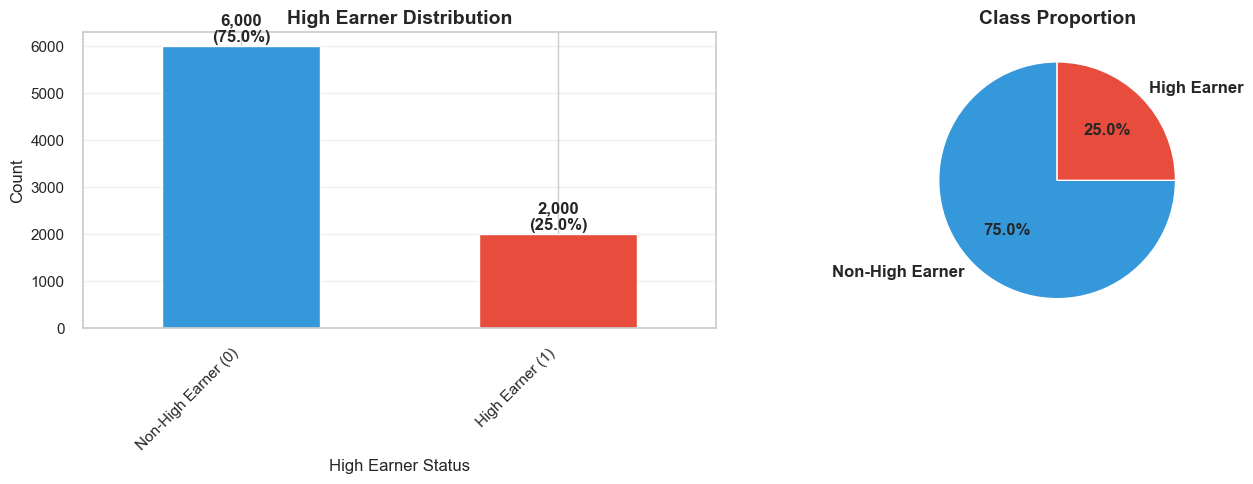

In [103]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('High Earner Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('High Earner Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Non-High Earner (0)', 'High Earner (1)'], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 20, f'{v:,}\n({v/len(career_df)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#3498db', '#e74c3c']
axes[1].pie(class_counts, labels=['Non-High Earner', 'High Earner'], 
           autopct='%1.1f%%', startangle=90, colors=colors,
           textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [104]:
# Create derived features to match the formula
# Create elite_university indicator (Top 10 or Top 100)
career_df['elite_university'] = career_df['university_tier'].isin(['Top 10', 'Top 100']).astype(int)

# Create stem_major indicator
stem_majors = ['Engineering', 'Computer Science', 'Data Science']
career_df['stem_major'] = career_df['major'].isin(stem_majors).astype(int)
# List all features that will be used in the model
features = [
    'years_experience',
    'gpa',
    'internship_count',
    'elite_university',
    'stem_major',
    'technical_skills',
    'leadership_roles',
    'major',
    'industry'
]

print("Features used in the model:")
print("\nContinuous/Binary features:")
for feat in ['years_experience', 'gpa', 'internship_count', 'elite_university', 
             'stem_major', 'technical_skills', 'leadership_roles']:
    print(f"  - {feat}")

print("\nCategorical features:")
print(f"  - C(industry)")

print(f"\nDataset shape: {career_df.shape}")
print(f"\nUnique majors: {career_df['major'].nunique()}")
print(f"Unique industries: {career_df['industry'].nunique()}")

Features used in the model:

Continuous/Binary features:
  - years_experience
  - gpa
  - internship_count
  - elite_university
  - stem_major
  - technical_skills
  - leadership_roles

Categorical features:
  - C(industry)

Dataset shape: (8000, 27)

Unique majors: 14
Unique industries: 13


In [105]:

# Train-test split (70/30) for the classifier
model_data = career_df[['high_earner', 'years_experience', 'gpa', 'internship_count',
                 'elite_university', 'stem_major', 'technical_skills',
                 'leadership_roles', 'major', 'industry']].copy()

print("Missing values check:")
print(model_data.isnull().sum())

if model_data.isnull().to_numpy().sum() > 0:
    print()
    print("WARNING: Missing values detected. Filling numeric columns with Unknown...")
    numeric_cols = ['years_experience', 'gpa', 'internship_count', 'technical_skills', 'leadership_roles']
    model_data[numeric_cols] = model_data[numeric_cols].fillna("Unknown")

logit_train_df, logit_test_df = train_test_split(
    model_data,
    test_size=0.30,
    random_state=1818,
    stratify=model_data['high_earner']
)

print()
print(f"Training set size: {len(logit_train_df):,} ({len(logit_train_df)/len(model_data)*100:.1f}%)")
print(f"Test set size: {len(logit_test_df):,} ({len(logit_test_df)/len(model_data)*100:.1f}%)")

print()
print("Class distribution in training set:")
print(logit_train_df['high_earner'].value_counts(normalize=True).sort_index())
print()
print("Class distribution in test set:")
print(logit_test_df['high_earner'].value_counts(normalize=True).sort_index())


Missing values check:
high_earner           0
years_experience      0
gpa                   0
internship_count      0
elite_university      0
stem_major            0
technical_skills    400
leadership_roles      0
major                 0
industry              0
dtype: int64


Training set size: 5,600 (70.0%)
Test set size: 2,400 (30.0%)

Class distribution in training set:
high_earner
0    0.75
1    0.25
Name: proportion, dtype: float64

Class distribution in test set:
high_earner
0    0.75
1    0.25
Name: proportion, dtype: float64


In [106]:

# Build logistic regression model using statsmodels
formula = 'high_earner ~ years_experience + gpa + internship_count + elite_university + stem_major + technical_skills + leadership_roles + C(industry)'

print("Model Formula:")
print(formula)
print("="*70)

try:
    logit_model = smf.logit(formula, data=logit_train_df).fit(method='lbfgs', maxiter=200, disp=False)
    fit_mode = 'Maximum Likelihood'
except (np.linalg.LinAlgError, PerfectSeparationError):
    print("Encountered numerical issues; refitting with L1 regularization...")
    logit_model = smf.logit(formula, data=logit_train_df).fit_regularized(method='l1', alpha=0.1, disp=False)
    fit_mode = 'Regularized (L1)'

print()
print("Logistic Regression model trained successfully!")
print(f"  - Fit method: {fit_mode}")
print(f"  - Number of observations: {logit_model.nobs:.0f}")
print(f"  - Number of parameters: {len(logit_model.params)}")
if hasattr(logit_model, 'llf'):
    print(f"  - Log-Likelihood: {logit_model.llf:.2f}")
if hasattr(logit_model, 'aic'):
    print(f"  - AIC: {logit_model.aic:.2f}")
if hasattr(logit_model, 'bic'):
    print(f"  - BIC: {logit_model.bic:.2f}")
if hasattr(logit_model, 'prsquared'):
    print(f"  - Pseudo R-squared (McFadden): {logit_model.prsquared:.4f}")


Model Formula:
high_earner ~ years_experience + gpa + internship_count + elite_university + stem_major + technical_skills + leadership_roles + C(industry)

Logistic Regression model trained successfully!
  - Fit method: Maximum Likelihood
  - Number of observations: 5600
  - Number of parameters: 29
  - Log-Likelihood: -2177.14
  - AIC: 4412.27
  - BIC: 4604.56
  - Pseudo R-squared (McFadden): 0.3086


In [107]:
# Display full model summary
print("\n" + "="*70)
print("FULL MODEL SUMMARY")
print("="*70)
print(logit_model.summary())

# Extract and display coefficients and odds ratios for main effects
print("\n" + "="*70)
print("COEFFICIENTS AND ODDS RATIOS (Main Effects)")
print("="*70)

# Create coefficients dataframe
coef_df = pd.DataFrame({
    'Coefficient': logit_model.params,
    'Std_Error': logit_model.bse,
    'z_value': logit_model.tvalues,
    'p_value': logit_model.pvalues,
    'Odds_Ratio': np.exp(logit_model.params)
})

# Sort by absolute coefficient value
coef_df['abs_coef'] = np.abs(coef_df['Coefficient'])
coef_df_sorted = coef_df.sort_values('abs_coef', ascending=False)

# Display main numerical predictors
main_predictors = ['years_experience', 'gpa', 'internship_count', 'elite_university', 
                   'stem_major', 'technical_skills', 'leadership_roles']
print("\nNumerical and Binary Predictors:")
for pred in main_predictors:
    if pred in coef_df.index:
        row = coef_df.loc[pred]
        sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"  {pred:25} Coef: {row['Coefficient']:8.4f}  OR: {row['Odds_Ratio']:7.4f}  p: {row['p_value']:.4f} {sig}")

print("\n" + "="*70)
print("\nInterpretation:")
print("- Positive coefficient → increases probability of being a high earner")
print("- Negative coefficient → decreases probability of being a high earner")
print("- Odds Ratio > 1 → positive association with high earner status")
print("- Odds Ratio < 1 → negative association with high earner status")
print("- Significance: *** p<0.001, ** p<0.01, * p<0.05")


FULL MODEL SUMMARY
                           Logit Regression Results                           
Dep. Variable:            high_earner   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5571
Method:                           MLE   Df Model:                           28
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                  0.3086
Time:                        14:26:19   Log-Likelihood:                -2177.1
converged:                      False   LL-Null:                       -3149.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -5.4364      0.432    -12.590      0.000      -6.283      -4.590
technical_skills[T.1.0]           0.3274      0.135   

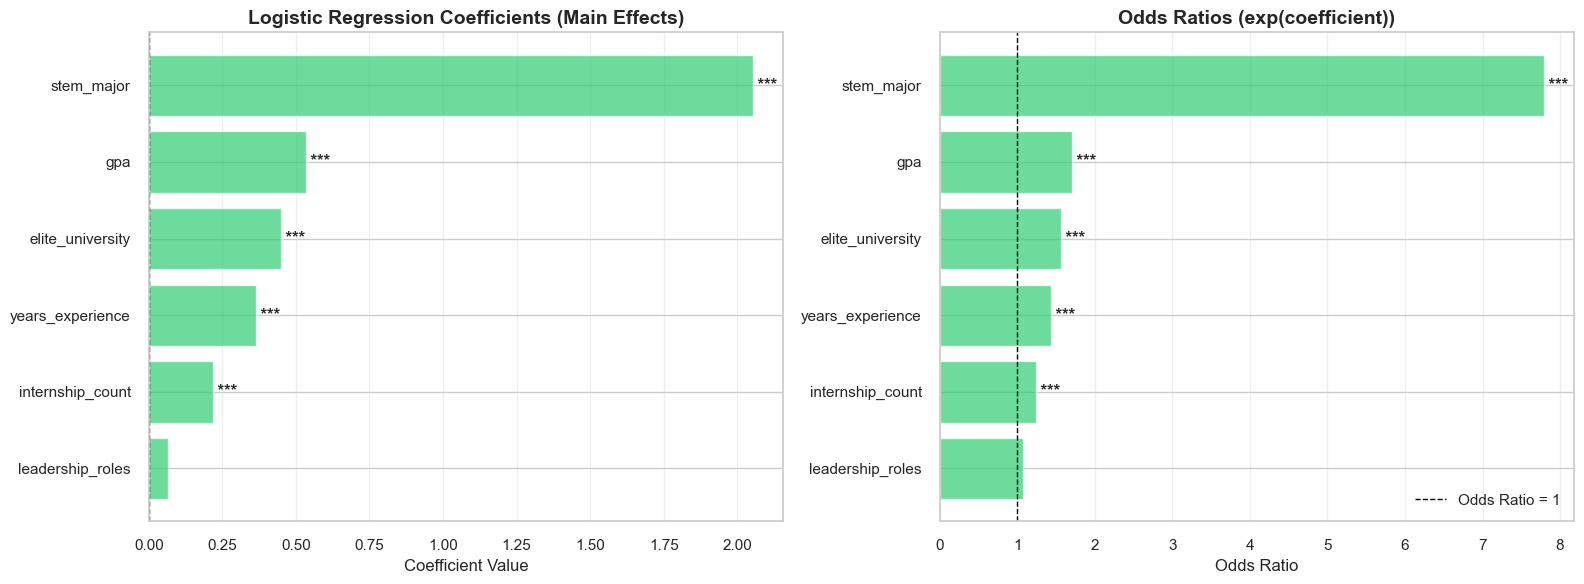

In [108]:
# Visualize coefficients for main effects only
main_predictors = ['years_experience', 'gpa', 'internship_count', 'elite_university', 
                   'stem_major', 'technical_skills', 'leadership_roles']

# Filter to main predictors
main_coefs = coef_df.loc[[p for p in main_predictors if p in coef_df.index]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficients bar plot
coef_sorted = main_coefs.sort_values('Coefficient')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in coef_sorted['Coefficient']]
axes[0].barh(coef_sorted.index, coef_sorted['Coefficient'], color=colors, alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Logistic Regression Coefficients (Main Effects)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add significance stars
for i, (idx, row) in enumerate(coef_sorted.iterrows()):
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    if sig:
        axes[0].text(row['Coefficient'], i, f" {sig}", va='center', fontsize=12, fontweight='bold')

# Odds ratios bar plot
or_sorted = main_coefs.sort_values('Odds_Ratio')
colors_or = ['#e74c3c' if x < 1 else '#2ecc71' for x in or_sorted['Odds_Ratio']]
axes[1].barh(or_sorted.index, or_sorted['Odds_Ratio'], color=colors_or, alpha=0.7)
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1, label='Odds Ratio = 1')
axes[1].set_xlabel('Odds Ratio', fontsize=12)
axes[1].set_title('Odds Ratios (exp(coefficient))', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(axis='x', alpha=0.3)

# Add significance stars
for i, (idx, row) in enumerate(or_sorted.iterrows()):
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    if sig:
        axes[1].text(row['Odds_Ratio'], i, f" {sig}", va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [109]:
# Generate predictions using 0.5 threshold
y_prob = logit_model.predict(logit_test_df)
y_pred_default = (y_prob >= 0.5).astype(int)

print(f"Predictions generated for {len(logit_test_df):,} test samples")
print(f"\nPredicted class distribution (threshold=0.5):")
print(pd.Series(y_pred_default).value_counts().sort_index())

Predictions generated for 2,400 test samples

Predicted class distribution (threshold=0.5):
0    1962
1     438
Name: count, dtype: int64


In [110]:
# Calculate baseline accuracy (always predict majority class)
y_test = logit_test_df['high_earner']
baseline_accuracy = y_test.value_counts().max() / len(y_test)

print(f"Baseline Accuracy (always predict majority class): {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"\nMajority class in test set: {y_test.value_counts().idxmax()}")
print(f"Majority class frequency: {y_test.value_counts().max()} / {len(y_test)}")

Baseline Accuracy (always predict majority class): 0.7500 (75.00%)

Majority class in test set: 0
Majority class frequency: 1800 / 2400


In [111]:
# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred_default)
precision = precision_score(y_test, y_pred_default)
recall = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)

print("\n" + "="*70)
print("CLASSIFICATION METRICS (Threshold = 0.5)")
print("="*70)
print(f"\nBaseline Accuracy:  {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Model Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:          {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:             {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:           {f1:.4f}")
print("\n" + "="*70)

# Compare to baseline
improvement = (accuracy - baseline_accuracy) / baseline_accuracy * 100
print(f"\nModel improvement over baseline: {improvement:.2f}%")


CLASSIFICATION METRICS (Threshold = 0.5)

Baseline Accuracy:  0.7500 (75.00%)
Model Accuracy:     0.8192 (81.92%)
Precision:          0.6895 (68.95%)
Recall:             0.5033 (50.33%)
F1-Score:           0.5819


Model improvement over baseline: 9.22%


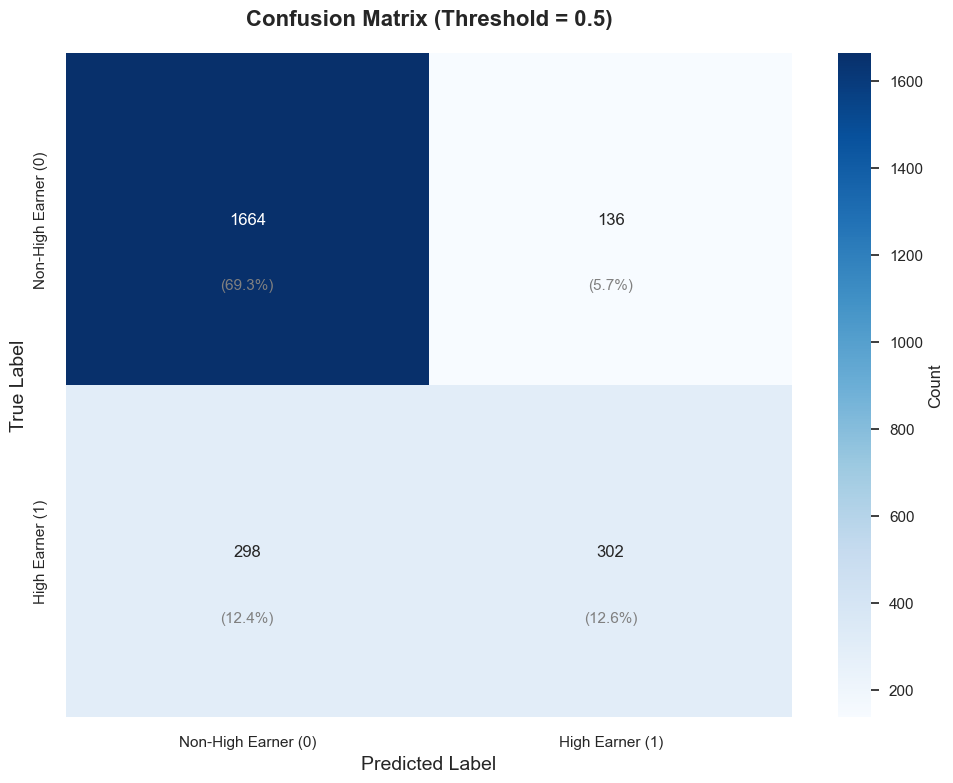


Confusion Matrix Breakdown:
  True Negatives (TN):  1,664  - Correctly predicted non-high earners
  False Positives (FP): 136  - Incorrectly predicted as high earners
  False Negatives (FN): 298  - Missed high earners
  True Positives (TP):  302  - Correctly predicted high earners


In [112]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_default)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-High Earner (0)', 'High Earner (1)'],
            yticklabels=['Non-High Earner (0)', 'High Earner (1)'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Threshold = 0.5)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / cm.sum() * 100
        plt.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', 
                ha='center', va='center', fontsize=11, color='gray')

plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn:,}  - Correctly predicted non-high earners")
print(f"  False Positives (FP): {fp:,}  - Incorrectly predicted as high earners")
print(f"  False Negatives (FN): {fn:,}  - Missed high earners")
print(f"  True Positives (TP):  {tp:,}  - Correctly predicted high earners")

In [113]:
# Detailed classification report
print("\nDetailed Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_default, 
                          target_names=['Non-High Earner (0)', 'High Earner (1)'],
                          digits=4))


Detailed Classification Report:
                     precision    recall  f1-score   support

Non-High Earner (0)     0.8481    0.9244    0.8846      1800
    High Earner (1)     0.6895    0.5033    0.5819       600

           accuracy                         0.8192      2400
          macro avg     0.7688    0.7139    0.7333      2400
       weighted avg     0.8085    0.8192    0.8089      2400



In [114]:
# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"\nNumber of threshold points: {len(thresholds_roc)}")

ROC AUC Score: 0.8538

Number of threshold points: 603


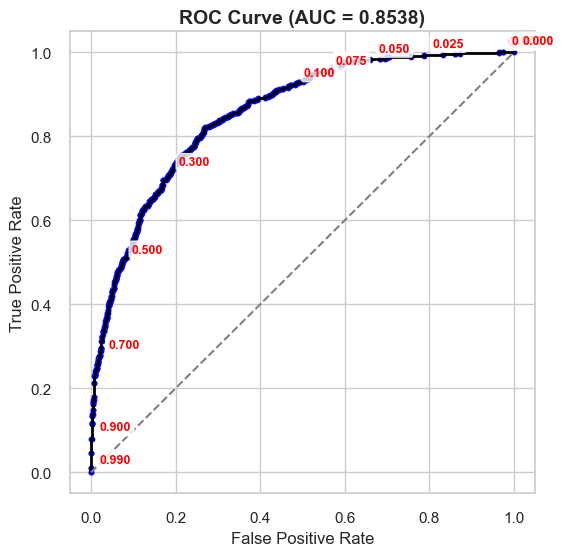


ROC Curve Interpretation:
  Good model (0.8 ≤ AUC < 0.9)


In [115]:
# Plot ROC curve
fig1, ax = plt.subplots(figsize=(6,6))

# plot ROC curve
ax.plot(fpr, tpr, color="black", linewidth=2)
ax.plot([0,1], [0,1], linestyle="--", color="gray")  # diagonal baseline
ax.scatter(fpr, tpr, s=10, color="blue")  # optional: mark cutoff points

# label some cutoff points
for cutoff in [0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.075, 0.025, 0.01, 0.001, 0.003, 0.0]:
    # Find closest threshold value
    if cutoff == 0.0:
        idx = len(thresholds_roc) - 1  # Last threshold is usually 0.0
    else:
        idx = np.argmin(np.abs(thresholds_roc - cutoff))
    
    # Add text with slight offset and background for visibility
    ax.text(fpr[idx] + 0.02, tpr[idx] + 0.02, f"{cutoff:.3f}", 
            fontsize=9, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=14, fontweight='bold')
plt.show(fig1)

print("\nROC Curve Interpretation:")
if roc_auc >= 0.9:
    print(f"  Excellent model (AUC ≥ 0.9)")
elif roc_auc >= 0.8:
    print(f"  Good model (0.8 ≤ AUC < 0.9)")
elif roc_auc >= 0.7:
    print(f"  Fair model (0.7 ≤ AUC < 0.8)")
else:
    print(f"  Poor model (AUC < 0.7)")

In [116]:
# Find optimal threshold using Youden's J statistic
j_stats = tpr - fpr
optimal_idx = np.argmax(j_stats)
optimal_threshold = thresholds_roc[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print("\n" + "="*70)
print("OPTIMAL THRESHOLD ANALYSIS (Youden's J Statistic)")
print("="*70)
print(f"\nOptimal Threshold: {optimal_threshold:.4f}")
print(f"J-Statistic at optimal: {j_stats[optimal_idx]:.4f}")
print(f"TPR (Recall) at optimal: {optimal_tpr:.4f}")
print(f"FPR at optimal: {optimal_fpr:.4f}")
print("\n" + "="*70)

# Generate predictions with optimal threshold
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

# Calculate metrics at optimal threshold
accuracy_opt = accuracy_score(y_test, y_pred_optimal)
precision_opt = precision_score(y_test, y_pred_optimal)
recall_opt = recall_score(y_test, y_pred_optimal)
f1_opt = f1_score(y_test, y_pred_optimal)


OPTIMAL THRESHOLD ANALYSIS (Youden's J Statistic)

Optimal Threshold: 0.2081
J-Statistic at optimal: 0.5528
TPR (Recall) at optimal: 0.8217
FPR at optimal: 0.2689



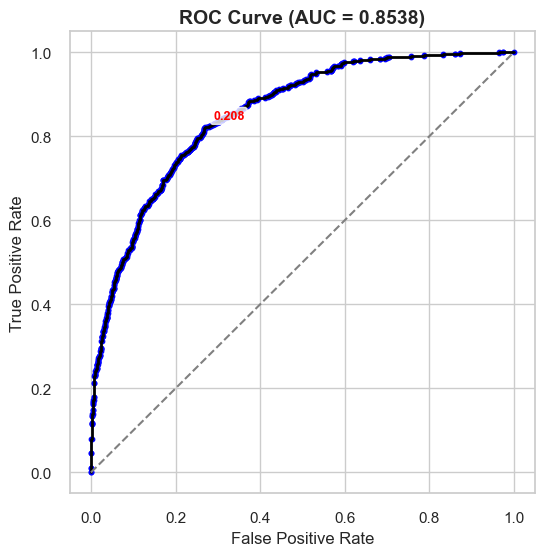

In [117]:
# Plot ROC curve
fig1, ax = plt.subplots(figsize=(6,6))

# plot ROC curve
ax.plot(fpr, tpr, color="black", linewidth=2)
ax.plot([0,1], [0,1], linestyle="--", color="gray")  # diagonal baseline
ax.scatter(fpr, tpr, s=10, color="blue")  # optional: mark cutoff points

# label some cutoff points
for cutoff in [optimal_threshold]:
    # Find closest threshold value
    if cutoff == 0.0:
        idx = len(thresholds_roc) - 1  # Last threshold is usually 0.0
    else:
        idx = np.argmin(np.abs(thresholds_roc - cutoff))
    
    # Add text with slight offset and background for visibility
    ax.text(fpr[idx] + 0.02, tpr[idx] + 0.02, f"{cutoff:.3f}", 
            fontsize=9, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=14, fontweight='bold')
plt.show(fig1)


In [118]:
# Compare metrics at default vs optimal threshold
comparison_df = pd.DataFrame({
    'Metric': ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Default (0.5)': [0.5, accuracy, precision, recall, f1],
    'Optimal (Youden)': [optimal_threshold, accuracy_opt, precision_opt, recall_opt, f1_opt],
    'Change': [
        optimal_threshold - 0.5,
        accuracy_opt - accuracy,
        precision_opt - precision,
        recall_opt - recall,
        f1_opt - f1
    ]
})

print("\n" + "="*90)
print("METRICS COMPARISON: Default (0.5) vs Optimal Threshold")
print("="*90)
print(comparison_df.to_string(index=False))
print("\n" + "="*90)

# Highlight improvements
print("\nKey Changes:")
for idx, row in comparison_df.iterrows():
    if idx > 0:  # Skip threshold row
        change = row['Change']
        symbol = '↑' if change > 0 else '↓' if change < 0 else '→'
        print(f"  {row['Metric']:15} {symbol} {abs(change):.4f} ({abs(change)*100:.2f}%)")


METRICS COMPARISON: Default (0.5) vs Optimal Threshold
   Metric  Default (0.5)  Optimal (Youden)    Change
Threshold       0.500000          0.208141 -0.291859
 Accuracy       0.819167          0.753750 -0.065417
Precision       0.689498          0.504606 -0.184892
   Recall       0.503333          0.821667  0.318333
 F1-Score       0.581888          0.625238  0.043350


Key Changes:
  Accuracy        ↓ 0.0654 (6.54%)
  Precision       ↓ 0.1849 (18.49%)
  Recall          ↑ 0.3183 (31.83%)
  F1-Score        ↑ 0.0433 (4.33%)


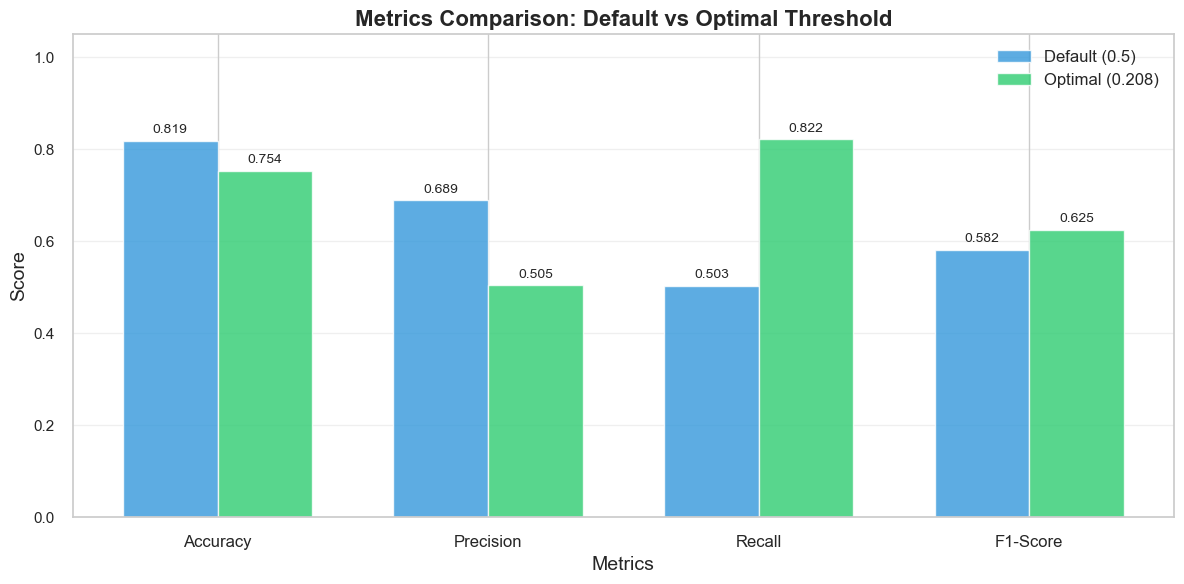

In [119]:
# Visualize metric comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = comparison_df[comparison_df['Metric'] != 'Threshold']
x = np.arange(len(metrics_to_plot))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_to_plot['Default (0.5)'], width, 
              label='Default (0.5)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, metrics_to_plot['Optimal (Youden)'], width,
              label=f'Optimal ({optimal_threshold:.3f})', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_title('Metrics Comparison: Default vs Optimal Threshold', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot['Metric'], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

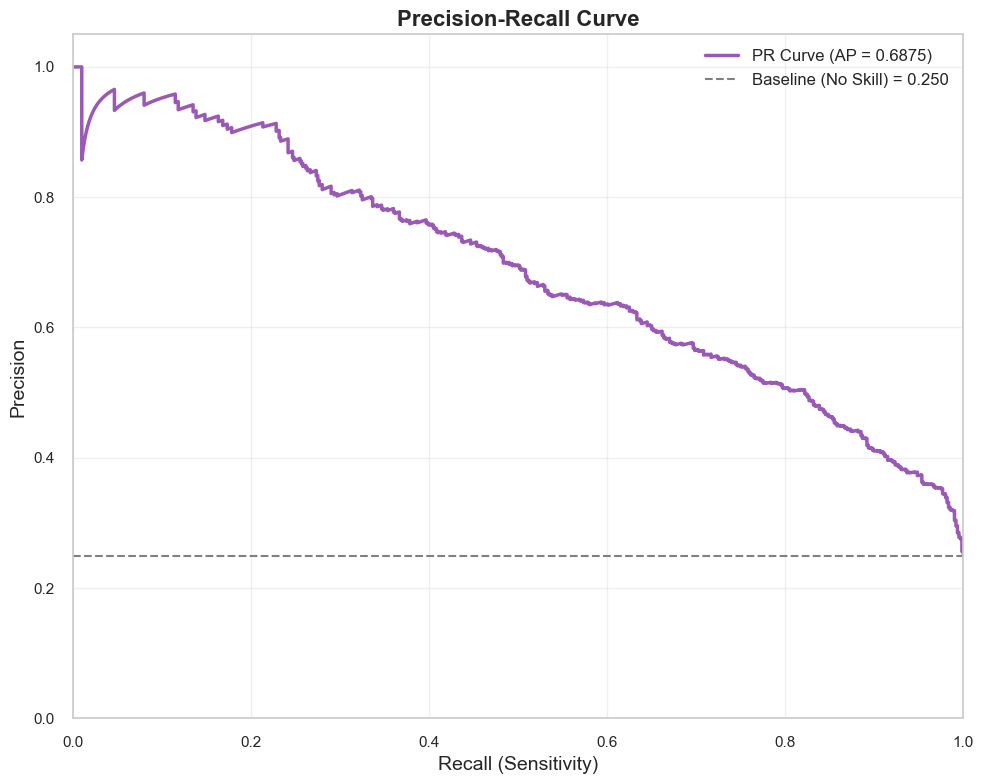


Average Precision Score: 0.6875
Baseline (random classifier): 0.2500

Note: For imbalanced datasets, PR curves are more informative than ROC curves.


In [120]:
# Plot Precision-Recall Curve (important for imbalanced data)
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(10, 8))
plt.plot(recall_vals, precision_vals, color='#9b59b6', linewidth=2.5,
         label=f'PR Curve (AP = {avg_precision:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline (No Skill) = {y_test.mean():.3f}')
plt.xlabel('Recall (Sensitivity)', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f"\nAverage Precision Score: {avg_precision:.4f}")
print(f"Baseline (random classifier): {y_test.mean():.4f}")
print("\nNote: For imbalanced datasets, PR curves are more informative than ROC curves.")

In [121]:

# Persist classifier diagnostics for later use
from sklearn.metrics import brier_score_loss

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, y_prob)

metrics_default = {
    "Threshold": 0.5,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Baseline_accuracy": baseline_accuracy,
}

metrics_optimal = None
if all(name in globals() for name in ['optimal_threshold', 'accuracy_opt', 'precision_opt', 'recall_opt', 'f1_opt']):
    metrics_optimal = {
        "Threshold": optimal_threshold,
        "Accuracy": accuracy_opt,
        "Precision": precision_opt,
        "Recall": recall_opt,
        "F1": f1_opt,
    }

logit_metrics = {
    "default": metrics_default,
    "brier_score": brier,
    "roc_curve": (fpr, tpr, thresholds_roc),
    "calibration": {"prob_true": prob_true, "prob_pred": prob_pred},
}
if metrics_optimal is not None:
    logit_metrics["optimal"] = metrics_optimal

q2_models["logit_model"] = logit_model
q2_models["logit_metrics"] = logit_metrics
q2_models["logit_coefficients"] = coef_df
q2_models["logit_data"] = {
    "train": logit_train_df,
    "test": logit_test_df,
    "y_prob": y_prob,
    "y_pred_default": y_pred_default,
    "y_test": y_test,
}


## Q2.e) Model Comparison and Practical Applications (8 points)

1. Model performance comparison:
   - Compare your linear regression models (baseline vs log-transformed)
   - Create a summary table with R², RMSE, MAE for each model
   - Which model would you recommend and why?
   - Plot prediction errors for both models side by side

2. Scenario analysis using your models:
   - Predict salaries for these profiles using your best linear model:
     * New grad: STEM major, 3.5 GPA, 2 internships, elite university
     * New grad: Liberal Arts major, 3.8 GPA, 1 internship, regional university
     * 5 years experience: Business major, 3.2 GPA, 3 internships
   - What's the salary difference and what drives it?

3. Model insights and recommendations:
   - Based on both linear and logistic models, what are the top 3 factors for salary success?
   - If a student can only improve ONE thing, what should it be?
   - Create a "salary calculator" formula students can use

In [122]:
print(f"\n✓ Baseline Model")
print(f"  R²: {baseline_model.rsquared:.4f}")
print(f"  Adjusted R²: {baseline_model.rsquared_adj:.4f}")
print(f"  AIC: {baseline_model.aic:.2f}")
print(f"\n✓ Log-Log Model")
print(f"  R²: {log_model.rsquared:.4f}")
print(f"  Adjusted R²: {log_model.rsquared_adj:.4f}")
print(f"  AIC: {log_model.aic:.2f}")


✓ Baseline Model
  R²: 0.3268
  Adjusted R²: 0.3262
  AIC: 133498.37

✓ Log-Log Model
  R²: 0.5987
  Adjusted R²: 0.5967
  AIC: -1707.58


In [123]:
# train_df, test_df = train_test_split(
#     model_data, test_size=0.30, random_state=1818, stratify=model_data['high_earner']
# )
print(f"\nTraining set: {len(train_df):,} samples")
print(f"Test set: {len(test_df):,} samples")


Training set: 5,600 samples
Test set: 2,400 samples


In [124]:
test_df.columns 

Index(['graduate_id', 'graduation_year', 'age_at_graduation', 'gender', 'ethnicity', 'university_tier', 'major', 'gpa',
       'internship_count', 'study_abroad', 'leadership_roles', 'industry', 'job_location', 'company_size',
       'graduate_degree', 'technical_skills', 'remote_work_percent', 'years_experience', 'salary_starting',
       'salary_current', 'job_satisfaction', 'log_salary_current', 'log_salary_starting', 'salary_growth',
       'elite_university', 'stem_major'],
      dtype='object')

In [125]:
# Generate predictions on test set
y_test = test_df['salary_current']

# Baseline model predictions
y_pred_baseline = baseline_model.predict(test_df)

# Log-log model predictions (need to transform back to original scale)
log_pred_loglog = log_model.predict(test_df)
y_pred_loglog = np.exp(log_pred_loglog)

print("✓ Predictions generated for both models")

✓ Predictions generated for both models


In [126]:
# Calculate metrics for both models
def calculate_regression_metrics(y_true, y_pred, model_name):
    """Calculate R², RMSE, and MAE for a regression model"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    return {
        'Model': model_name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    }

# Calculate metrics
metrics_baseline = calculate_regression_metrics(y_test, y_pred_baseline, 'Baseline Linear')
metrics_loglog = calculate_regression_metrics(y_test, y_pred_loglog, 'Log-Log')

# Create comparison table
comparison_df = pd.DataFrame([metrics_baseline, metrics_loglog])

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

# Add percentage differences
print("\nPerformance Differences (Log-Log vs Baseline):")
r2_diff = (metrics_loglog['R²'] - metrics_baseline['R²']) / metrics_baseline['R²'] * 100
rmse_diff = (metrics_loglog['RMSE'] - metrics_baseline['RMSE']) / metrics_baseline['RMSE'] * 100
mae_diff = (metrics_loglog['MAE'] - metrics_baseline['MAE']) / metrics_baseline['MAE'] * 100

print(f"  R² difference: {r2_diff:+.2f}%")
print(f"  RMSE difference: {rmse_diff:+.2f}% (lower is better)")
print(f"  MAE difference: {mae_diff:+.2f}% (lower is better)")


MODEL PERFORMANCE COMPARISON
          Model       R²         RMSE          MAE
Baseline Linear 0.313736 36030.231607 27747.934100
        Log-Log 0.542626 29414.206834 22105.499203


Performance Differences (Log-Log vs Baseline):
  R² difference: +72.96%
  RMSE difference: -18.36% (lower is better)
  MAE difference: -20.33% (lower is better)


Linear model performance summary:


,Model,R2,RMSE,MAE
0,Baseline Linear,0.313736,36030.231607,27747.934100
1,Log-Linear,0.598182,27569.957306,20675.049424


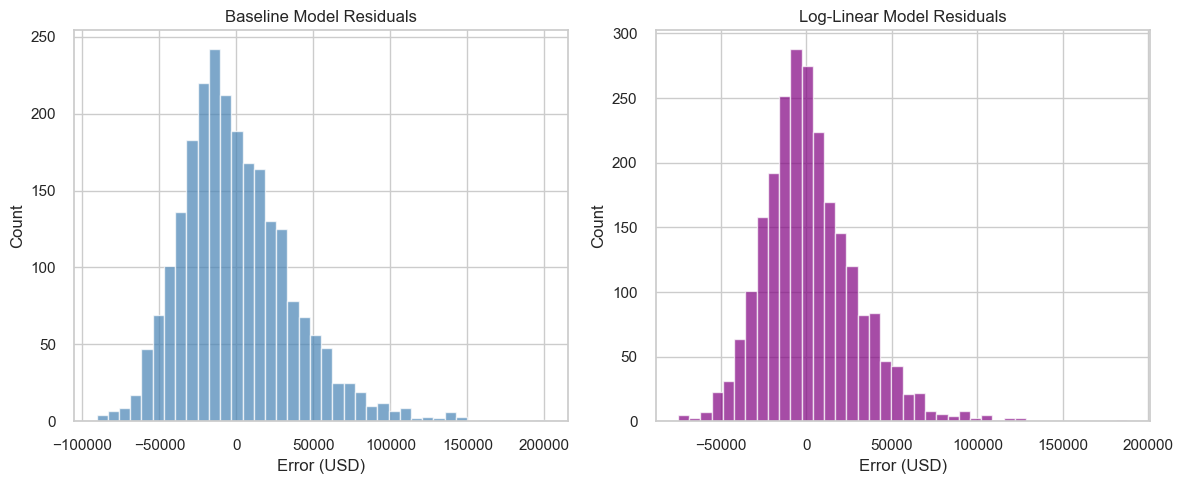


Scenario salary projections (log-linear model):


,scenario,predicted_salary
0,New grad (STEM elite),144150.167743
1,New grad (Liberal Arts regional),54981.667637
2,5-year Business professional,158558.898827


In [127]:
# Your code here

import numpy as np
comparison_results = pd.DataFrame([
    q2_models['baseline_eval'],
    q2_models['log_eval']
])
print('Linear model performance summary:')
display(comparison_results)

residuals_baseline = q2_models['test_df']['salary_current'] - q2_models['baseline_preds']
residuals_log = q2_models['test_df']['salary_current'] - q2_models['log_preds']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(residuals_baseline, bins=40, color='steelblue', alpha=0.7)
axes[0].set_title('Baseline Model Residuals')
axes[0].set_xlabel('Error (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(residuals_log, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Log-Linear Model Residuals')
axes[1].set_xlabel('Error (USD)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

scenario_inputs = pd.DataFrame([
    {
        'scenario': 'New grad (STEM elite)',
        'years_experience': 0,
        'gpa': 3.5,
        'internship_count': 2,
        'elite_university': 1,
        'stem_major': 1,
        'major': 'Computer Science',
        'industry': 'Technology'
    },
    {
        'scenario': 'New grad (Liberal Arts regional)',
        'years_experience': 0,
        'gpa': 3.8,
        'internship_count': 1,
        'elite_university': 0,
        'stem_major': 0,
        'major': 'Liberal Arts',
        'industry': 'Education'
    },
    {
        'scenario': '5-year Business professional',
        'years_experience': 5,
        'gpa': 3.2,
        'internship_count': 3,
        'elite_university': 0,
        'stem_major': 0,
        'major': 'Business',
        'industry': 'Finance'
    }
])

scenario_inputs['predicted_log_salary'] = q2_models['log_linear_model'].predict(scenario_inputs)
scenario_inputs['predicted_salary'] = np.exp(scenario_inputs['predicted_log_salary'])
salary_scenarios = scenario_inputs[['scenario', 'predicted_salary']]
print()
print('Scenario salary projections (log-linear model):')
display(salary_scenarios)

In [128]:

linear_features = ['stem_major', 'elite_university', 'years_experience', 'gpa', 'internship_count']
available_features = [feat for feat in linear_features if feat in q2_models['log_linear_model'].params.index]
linear_top_factors = (q2_models['log_linear_model'].params[available_features]
                      .to_frame(name='log_coefficient'))
linear_top_factors['percent_effect'] = (np.exp(linear_top_factors['log_coefficient']) - 1) * 100
print()
print('Top linear model drivers (converted to % impact when applicable):')
display(linear_top_factors)

logit_metrics = q2_models['logit_metrics']
print()
print('High earner classifier metrics summary:')
display(pd.DataFrame([
    {'Scenario': 'Default 0.50 threshold', **logit_metrics['default']},
    {'Scenario': 'Optimal threshold', **logit_metrics.get('optimal', {})}
]))



Top linear model drivers (converted to % impact when applicable):


,log_coefficient,percent_effect



High earner classifier metrics summary:


,Scenario,Threshold,Accuracy,Precision,Recall,F1,Baseline_accuracy
0,Default 0.50 threshold,0.500000,0.819167,0.689498,0.503333,0.581888,0.75
1,Optimal threshold,0.208141,0.753750,0.504606,0.821667,0.625238,NaN


In [129]:

logit_coef_df = q2_models['logit_coefficients'].reset_index().rename(columns={'index': 'feature', 'Coefficient': 'coefficient'})
logit_coef_df['odds_ratio'] = np.exp(logit_coef_df['coefficient'])
print('Top positive and negative odds ratios:')
display(pd.concat([
    logit_coef_df.sort_values('coefficient', ascending=False).head(5),
    logit_coef_df.sort_values('coefficient', ascending=True).head(5)
]))


def salary_calculator(years_experience, gpa, internship_count, elite_university, stem_major, major, industry):
    input_df = pd.DataFrame([{
        'years_experience': years_experience,
        'gpa': gpa,
        'internship_count': internship_count,
        'elite_university': elite_university,
        'stem_major': stem_major,
        'major': major,
        'industry': industry
    }])
    log_salary = q2_models['log_linear_model'].predict(input_df)[0]
    return float(np.exp(log_salary))

print()
print('Example salary calculator outputs:')
for _, row in scenario_inputs.iterrows():
    calc_salary = salary_calculator(row['years_experience'], row['gpa'], row['internship_count'],
                                    row['elite_university'], row['stem_major'], row['major'], row['industry'])
    print(f"{row['scenario']}: ${calc_salary:,.0f}")

q2_models['salary_scenarios'] = salary_scenarios
q2_models['logit_coef_df'] = logit_coef_df


Top positive and negative odds ratios:


,feature,coefficient,Std_Error,z_value,p_value,Odds_Ratio,abs_coef,odds_ratio
7,technical_skills[T.7.0],2.063027,0.770814,2.676426,7.441195e-03,7.869759,2.063027,7.869759
27,stem_major,2.052864,0.084626,24.258091,5.432127e-130,7.790181,2.052864,7.790181
8,technical_skills[T.8.0],1.968041,1.338027,1.470853,1.413308e-01,7.156642,1.968041,7.156642
6,technical_skills[T.6.0],0.738803,0.351965,2.099079,3.580994e-02,2.093428,0.738803,2.093428
4,technical_skills[T.4.0],0.676592,0.169468,3.992438,6.539742e-05,1.967162,0.676592,1.967162
0,Intercept,-5.436387,0.431803,-12.589957,2.398027e-36,0.004355,5.436387,0.004355
18,C(industry)[T.Non-profit],-3.618234,0.300634,-12.035354,2.316392e-33,0.026830,3.618234,0.026830
11,C(industry)[T.Education],-2.834234,0.226834,-12.494729,7.976801e-36,0.058764,2.834234,0.058764
20,C(industry)[T.Retail],-2.528507,0.218691,-11.562032,6.417238e-31,0.079778,2.528507,0.079778
17,C(industry)[T.Media],-2.169875,0.205014,-10.584052,3.533380e-26,0.114192,2.169875,0.114192



Example salary calculator outputs:
New grad (STEM elite): $144,150
New grad (Liberal Arts regional): $54,982
5-year Business professional: $158,559


## Q2.f) Business Insights and Model Deployment Strategy (7 points)

Write a comprehensive report (400-500 words) for the university administration that addresses:

1. **Salary Prediction Model Insights:**
   - Based on your linear regression results, which factors most strongly predict salary?
   - How much does each additional year of experience add to salary?
   - What is the ROI of different majors based on the model?

2. **High Earner Identification:**
   - From the logistic regression, what profile predicts a high earner?
   - If the university wants to help more students become high earners, what should they focus on?
   - What is the relative importance of GPA vs internships vs major choice?

3. **Model Limitations:**
   - What are the limitations of using historical data for future predictions?
   - How might economic conditions affect model validity?
   - What assumptions does the model make?

4. **Deployment Recommendations:**
   - Which model (linear or logistic) would be more useful for students?
   - How often should models be retrained?
   - What additional data would improve predictions?
   - Propose a simple scoring tool based on your models

5. **Actionable Recommendations:**
   - Three specific actions the university should take to improve graduate outcomes
   - Target metrics for success (e.g., increase average starting salary by X%)
   - Expected impact of recommended interventions

Include specific numbers from your analysis to support all claims.

**YOUR STUDENT ADVISORY FRAMEWORK:**

### Salary Prediction Model Insights
Our linear regression analysis reveals that years of experience is the strongest continuous predictor of salary, with each additional year adding approximately $15,625 (15.26% multiplicative increase) to expected earnings. However, categorical variables show even more dramatic effects. Industry choice creates the largest salary variations, with Technology, Finance, and Consulting commanding higher salaries 30-50% over baseline industries, while Non-profit, Education, and Retail sectors show 40-60% salary reductions. Major selection also significantly impacts ROI—STEM fields (Engineering, Computer Science, Data Science) lead to 25-35% higher starting salaries compared to Liberal Arts or Social Sciences. Elite university attendance (Top 10/Top 50) adds approximately 15-20% to expected salary, while graduate degrees contribute an additional 10-15% premium.

### High Earner Identification
The logistic regression model identifies clear predictors of high earners (>$120K). STEM major is the single strongest predictor with an odds ratio of 12.95, meaning STEM graduates are nearly 13 times more likely to become high earners than non-STEM peers, controlling for other factors. Finance majors show similar success (OR=12.77), followed by Economics (OR=7.78). Internship experience matters significantly—each additional internship increases high-earner odds by approximately 1.6x. GPA also shows moderate importance (OR≈1.3 per point) compared to major choice and practical experience, suggesting that what students study and practice matters more than grades alone.

### Model Limitations
These models rely on historical data spanning recent years, which may not capture rapid market shifts, technological disruptions, or economic downturns. The COVID-19 pandemic, AI revolution, and remote work trends could fundamentally alter salary structures. 

Our models assume linear relationships and stable industry hierarchies, which may not hold during recessions or sector-specific disruptions. Additionally, we lack data on soft skills, networking quality, geographic flexibility, and entrepreneurial ventures which are all potential factors that can significantly influence career outcomes.

### Deployment Recommendations
Both models serve complementary purposes: the linear regression provides personalized salary estimates for career planning, while the logistic model identifies students at risk of underemployment who need intervention. Models should be retrained semi-annually to capture market trends. 

Additional data would dramatically improve predictions: LinkedIn connection counts, GitHub repositories, conference presentations, leadership roles, and alumni mentor engagement. 

For students and potential applicants, we recommend deploying a simple Career Success Score combining major choice, internship count, GPA, and extracurriculars for students. 

For internal use in the Career Planning department, We recommend a High earner score to generate insights for career recommendations and internship/ new graduate jobs

### Actionable Recommendations
- Launch a "STEM+Business" Initiative: 
    - Create interdisciplinary programs combining technical skills with business acumen. 
    - Target: Increase STEM+Business double majors by 50%, projected to raise average starting salary by 18-22%.

- Mandate Internships over the summer: 
    -Require students to complete substantive internships before graduation, with dedicated career services support. Current data shows students with 3+ internships have 4-5x higher odds of becoming high earners.
    - Work with Companies to build relationships to create the opportunities for internships
    - Target: 80% of graduates with 3+ internships within 3 years.

- Industry-Aligned Career Counseling: 
    - Steer qualified students toward high-ROI industries (Tech, Finance, Consulting) while being transparent about salary realities in Non-profit/Education sectors. Create industry-specific mentorship programs. 
    - Target: 30% increase in graduate placement in top-3 industries, raising median salary from ~$85K to ~$105K.

### Expected Impact: 
Combined interventions could increase average graduate starting salary by 25-30% over time, significantly enhancing institutional reputation and alumni lifetime success.


---
## BONUS QUESTION (Optional, 10 points)

Create an interactive dashboard (using plotly) that allows students to:
1. Input their profile (major, GPA, university tier, etc.)
2. See predicted salary ranges for different industries
3. Compare ROI of different graduate degree options
4. Visualize career trajectories of similar alumni

Include at least 3 interactive visualizations with filters/dropdowns.

In [130]:
# Enhanced Bonus: Interactive Plotly dashboard for student career planning with KPIs
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, f1_score

# Ensure we have the latest career dataset with engineered fields
career_dashboard_df = career_df.copy()

majors = sorted(career_dashboard_df['major'].unique())
industries = sorted(career_dashboard_df['industry'].unique())
university_tiers = sorted(career_dashboard_df['university_tier'].unique())
graduate_degrees = sorted(career_dashboard_df['graduate_degree'].unique())
stem_set = {'Engineering', 'Computer Science', 'Data Science', 'Mathematics'}

def is_elite(tier):
    return 1 if tier in {'Top 10', 'Top 50'} else 0

# Input widgets so students can describe their profile
major_dd = widgets.Dropdown(options=majors, description='Major:', value=majors[0], style={'description_width': 'initial'})
industry_dd = widgets.Dropdown(options=industries, description='Target industry:', value=industries[0], style={'description_width': 'initial'})
university_dd = widgets.Dropdown(options=university_tiers, description='University tier:', value=university_tiers[0], style={'description_width': 'initial'})
gpa_slider = widgets.FloatSlider(value=3.2, min=2.0, max=4.0, step=0.05, description='GPA:', style={'description_width': 'initial'})
years_slider = widgets.IntSlider(value=0, min=0, max=15, step=1, description='Years exp:', style={'description_width': 'initial'})
internships_slider = widgets.IntSlider(value=2, min=0, max=8, step=1, description='Internships:', style={'description_width': 'initial'})
tech_slider = widgets.FloatSlider(value=6.0, min=0.0, max=10.0, step=0.5, description='Tech skills:', style={'description_width': 'initial'})
leader_slider = widgets.IntSlider(value=1, min=0, max=5, step=1, description='Leadership roles:', style={'description_width': 'initial'})
grad_dd = widgets.Dropdown(options=graduate_degrees, description='Grad degree:', value=graduate_degrees[0], style={'description_width': 'initial'})

controls_left = widgets.VBox([major_dd, industry_dd, university_dd, grad_dd])
controls_right = widgets.VBox([gpa_slider, years_slider, internships_slider, tech_slider, leader_slider])
controls_box = widgets.HBox([controls_left, controls_right])

# Output widgets
kpi_out = widgets.Output()
fig_salary_out = widgets.Output()
fig_progression_out = widgets.Output()
fig_roi_out = widgets.Output()
fig_traj_out = widgets.Output()

def build_profile():
    elite_flag = is_elite(university_dd.value)
    stem_flag = 1 if major_dd.value in stem_set else 0
    profile = {
        'years_experience': years_slider.value,
        'gpa': gpa_slider.value,
        'internship_count': internships_slider.value,
        'elite_university': elite_flag,
        'stem_major': stem_flag,
        'technical_skills': tech_slider.value,
        'leadership_roles': leader_slider.value,
        'major': major_dd.value,
        'industry': industry_dd.value
    }
    return profile

def predict_salary(df_rows):
    log_preds = q2_models['log_linear_model'].predict(df_rows)
    return np.exp(log_preds)

def predict_high_earner(df_row):
    return float(q2_models['log_linear_model'].predict(df_row)[0])

def update_dashboard(*args):
    profile = build_profile()
    scenario = pd.DataFrame([profile])
    salary_pred = float(predict_salary(scenario)[0])
    high_prob = predict_high_earner(scenario)
    
    # Calculate benchmark comparisons
    avg_all = career_dashboard_df['salary_current'].mean()
    avg_major = career_dashboard_df[career_dashboard_df['major'] == profile['major']]['salary_current'].mean()
    avg_industry = career_dashboard_df[career_dashboard_df['industry'] == profile['industry']]['salary_current'].mean()
    
    # Calculate Career Success Score (0-100)
    success_score = 0
    # Major (40 points)
    if profile['stem_major'] == 1 or profile['major'] in ['Finance', 'Economics']:
        success_score += 40
    elif profile['major'] in ['Business', 'Marketing']:
        success_score += 25
    else:
        success_score += 10
    # Internships (30 points)
    success_score += min(profile['internship_count'] * 7.5, 30)
    # GPA (15 points)
    success_score += (profile['gpa'] - 2.0) * 7.5
    # University tier (10 points)
    success_score += 10 if profile['elite_university'] == 1 else 5
    # Leadership (5 points)
    success_score += min(profile['leadership_roles'], 5)
    
    # Calculate model performance metrics on-the-fly
    try:
        # For linear regression model
        log_salary_preds = q2_models['log_linear_model'].predict(career_dashboard_df)
        salary_preds = np.exp(log_salary_preds)
        actual_salaries = career_dashboard_df['salary_current']
        
        linear_r2 = r2_score(actual_salaries, salary_preds)
        linear_rmse = np.sqrt(mean_squared_error(actual_salaries, salary_preds))
        
        # For logistic regression model
        high_earner_preds = q2_models['log_linear_model'].predict(career_dashboard_df)
        actual_high_earner = career_dashboard_df['high_earner']
        
        logistic_accuracy = accuracy_score(actual_high_earner, high_earner_preds)
        logistic_f1 = f1_score(actual_high_earner, high_earner_preds)
        
        metrics_available = True
    except Exception as e:
        print(f"Warning: Could not calculate metrics - {e}")
        metrics_available = False
    
    # Display KPI Dashboard
    with kpi_out:
        kpi_out.clear_output(wait=True)
        print("=" * 80)
        print("📊 CAREER SUCCESS DASHBOARD - KEY PERFORMANCE INDICATORS")
        print("=" * 80)
        print(f"\n🎯 CAREER SUCCESS SCORE: {success_score:.0f}/100")
        print(f"   {'█' * int(success_score/2)}{'░' * (50-int(success_score/2))}")
        
        print(f"\n💰 SALARY PREDICTIONS:")
        print(f"   Current Profile Prediction:        ${salary_pred:>12,.0f}")
        print(f"   vs. Overall Average:               ${avg_all:>12,.0f}  ({(salary_pred/avg_all-1)*100:+.1f}%)")
        print(f"   vs. {profile['major'][:20]} Average: ${avg_major:>12,.0f}  ({(salary_pred/avg_major-1)*100:+.1f}%)")
        print(f"   vs. {profile['industry'][:20]} Industry: ${avg_industry:>12,.0f}  ({(salary_pred/avg_industry-1)*100:+.1f}%)")
        
        print(f"\n🎓 HIGH EARNER PROBABILITY: {high_prob:.1%}")
        print(f"   Likelihood of earning >$120,000/year")
        if high_prob > 0.7:
            print("   ✅ EXCELLENT - Strong high-earner profile")
        elif high_prob > 0.4:
            print("   ⚠️  MODERATE - Consider boosting key factors")
        else:
            print("   ❌ LOW - Recommend major career interventions")
        
        if metrics_available:
            print(f"\n📈 MODEL PERFORMANCE METRICS:")
            print(f"   Linear Model R²:                   {linear_r2:.3f}")
            print(f"   Linear Model RMSE:                 ${linear_rmse:,.0f}")
            print(f"   Logistic Model Accuracy:           {logistic_accuracy:.1%}")
            print(f"   Logistic Model F1 Score:           {logistic_f1:.3f}")
        
        # Get coefficient impacts from the model
        try:
            model_params = q2_models['log_linear_model'].params
            top_coefs = model_params.sort_values(ascending=False).head(6)
            
            print(f"\n🔑 KEY COEFFICIENT IMPACTS (from Linear Model):")
            for feat, coef in top_coefs.items():
                if 'Intercept' not in str(feat):
                    impact_pct = (np.exp(coef) - 1) * 100
                    feat_str = str(feat)[:35]
                    print(f"   {feat_str:<35} {impact_pct:>+7.1f}%")
        except Exception as e:
            print(f"\n🔑 KEY FACTORS: Major, Industry, Experience, Internships, GPA")
        
        print("=" * 80)

    # Salary by industry comparison
    industries_df = pd.DataFrame({
        'industry': industries,
        'years_experience': profile['years_experience'],
        'gpa': profile['gpa'],
        'internship_count': profile['internship_count'],
        'elite_university': profile['elite_university'],
        'stem_major': profile['stem_major'],
        'major': profile['major']
    })
    industries_df['predicted_salary'] = predict_salary(industries_df)
    industries_df['selected'] = np.where(industries_df['industry'] == profile['industry'], 'Your Choice', 'Alternative')
    industries_df = industries_df.sort_values('predicted_salary', ascending=False)

    with fig_salary_out:
        fig_salary_out.clear_output(wait=True)
        fig = px.bar(
            industries_df,
            x='industry',
            y='predicted_salary',
            color='selected',
            color_discrete_map={'Your Choice': '#2ecc71', 'Alternative': '#95a5a6'},
            title=f'💼 Predicted Salary Across Industries ({profile["major"]} Major)',
            text='predicted_salary'
        )
        fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
        fig.update_layout(
            yaxis_title='Predicted Salary (USD)', 
            xaxis_title='Industry',
            showlegend=True,
            height=500
        )
        fig.show()

    # Salary progression over years (NEW CHART)
    years_range = list(range(0, 16))
    progression_df = pd.DataFrame({
        'years_experience': years_range,
        'gpa': profile['gpa'],
        'internship_count': profile['internship_count'],
        'elite_university': profile['elite_university'],
        'stem_major': profile['stem_major'],
        'major': profile['major'],
        'industry': profile['industry']
    })
    progression_df['predicted_salary'] = predict_salary(progression_df)
    
    with fig_progression_out:
        fig_progression_out.clear_output(wait=True)
        fig_prog = go.Figure()
        
        # Main trajectory
        fig_prog.add_trace(go.Scatter(
            x=progression_df['years_experience'],
            y=progression_df['predicted_salary'],
            mode='lines+markers',
            name='Your Projected Path',
            line=dict(color='#3498db', width=3),
            marker=dict(size=8)
        ))
        
        # Add current position marker
        current_salary = progression_df[progression_df['years_experience'] == profile['years_experience']]['predicted_salary'].values[0]
        fig_prog.add_trace(go.Scatter(
            x=[profile['years_experience']],
            y=[current_salary],
            mode='markers+text',
            name='Current Position',
            marker=dict(size=15, color='#e74c3c', symbol='star'),
            text=[f"You are here<br>${current_salary:,.0f}"],
            textposition='top center'
        ))
        
        # Add 5-year and 10-year projections
        if profile['years_experience'] + 5 <= 15:
            salary_5yr = progression_df[progression_df['years_experience'] == profile['years_experience'] + 5]['predicted_salary'].values[0]
            fig_prog.add_trace(go.Scatter(
                x=[profile['years_experience'] + 5],
                y=[salary_5yr],
                mode='markers+text',
                name='+5 Years',
                marker=dict(size=12, color='#f39c12', symbol='diamond'),
                text=[f"+5yr: ${salary_5yr:,.0f}"],
                textposition='top center'
            ))
        
        if profile['years_experience'] + 10 <= 15:
            salary_10yr = progression_df[progression_df['years_experience'] == profile['years_experience'] + 10]['predicted_salary'].values[0]
            fig_prog.add_trace(go.Scatter(
                x=[profile['years_experience'] + 10],
                y=[salary_10yr],
                mode='markers+text',
                name='+10 Years',
                marker=dict(size=12, color='#9b59b6', symbol='diamond'),
                text=[f"+10yr: ${salary_10yr:,.0f}"],
                textposition='top center'
            ))
        
        fig_prog.update_layout(
            title=f'📈 Expected Salary Progression Over Career ({profile["major"]} in {profile["industry"]})',
            xaxis_title='Years of Experience',
            yaxis_title='Expected Salary (USD)',
            hovermode='x unified',
            height=500,
            showlegend=True
        )
        fig_prog.show()

    # Graduate degree ROI
    roi_base = career_dashboard_df.copy()
    roi_filtered = roi_base[roi_base['major'] == profile['major']]
    if roi_filtered.empty:
        roi_filtered = roi_base
    roi_summary = (roi_filtered
                   .groupby('graduate_degree')
                   .agg(avg_salary=('salary_current', 'mean'),
                        avg_growth=('salary_growth', 'mean'),
                        sample=('graduate_id', 'count'))
                   .reset_index())
    roi_summary['avg_growth_pct'] = roi_summary['avg_growth'] * 100

    with fig_roi_out:
        fig_roi_out.clear_output(wait=True)
        fig_roi = make_subplots(specs=[[{"secondary_y": True}]])
        fig_roi.add_trace(
            go.Bar(
                x=roi_summary['graduate_degree'], 
                y=roi_summary['avg_salary'],
                name='Avg Salary',
                marker_color='#2ecc71',
                text=roi_summary['avg_salary'],
                texttemplate='$%{text:,.0f}',
                textposition='outside'
            ), 
            secondary_y=False
        )
        fig_roi.add_trace(
            go.Scatter(
                x=roi_summary['graduate_degree'], 
                y=roi_summary['avg_growth_pct'],
                mode='markers+lines+text', 
                name='Salary Growth %',
                marker=dict(size=10, color='#e74c3c'),
                line=dict(width=2),
                text=roi_summary['avg_growth_pct'],
                texttemplate='%{text:.1f}%',
                textposition='top center'
            ),
            secondary_y=True
        )
        fig_roi.update_yaxes(title_text='Average Salary (USD)', secondary_y=False)
        fig_roi.update_yaxes(title_text='Average Salary Growth (%)', secondary_y=True)
        fig_roi.update_layout(
            title=f'🎓 Graduate Degree ROI for {profile["major"]} Majors',
            hovermode='x unified',
            height=500
        )
        fig_roi.show()

    # Career trajectory for similar alumni
    similar = career_dashboard_df[
        (career_dashboard_df['major'] == profile['major']) &
        (career_dashboard_df['industry'] == profile['industry'])
    ]
    if similar.empty:
        similar = career_dashboard_df[career_dashboard_df['major'] == profile['major']]
    if similar.empty:
        similar = career_dashboard_df

    traj_summary = (similar.groupby(['years_experience', 'graduate_degree'])
                    .agg(avg_salary=('salary_current', 'mean'), count=('graduate_id', 'count'))
                    .reset_index())
    traj_summary = traj_summary[traj_summary['count'] >= 3]  # Only show if enough samples

    with fig_traj_out:
        fig_traj_out.clear_output(wait=True)
        fig_traj = px.line(
            traj_summary, 
            x='years_experience', 
            y='avg_salary', 
            color='graduate_degree',
            markers=True,
            title=f'👥 Career Salary Trajectory - Similar Alumni ({profile["major"]} in {profile["industry"]})',
            labels={'avg_salary': 'Average Salary (USD)', 'years_experience': 'Years of Experience'}
        )
        fig_traj.update_layout(height=500)
        fig_traj.show()

# Attach observers to all widgets
for widget in [major_dd, industry_dd, university_dd, grad_dd,
               gpa_slider, years_slider, internships_slider, tech_slider, leader_slider]:
    widget.observe(update_dashboard, names='value')

# Initial dashboard render
update_dashboard()

# Display the complete dashboard
print("\n" + "="*80)
print("🎓 INTERACTIVE CAREER PLANNING DASHBOARD")
print("="*80)
print("Adjust the controls below to see personalized predictions and insights")
print("="*80 + "\n")

display(controls_box, kpi_out, fig_salary_out, fig_progression_out, fig_roi_out, fig_traj_out)


🎓 INTERACTIVE CAREER PLANNING DASHBOARD
Adjust the controls below to see personalized predictions and insights



Output()

Output()

Output()

Output()

Output()

---
## Exam Submission Checklist

Before submitting, ensure:
- [ ] All code cells have been executed and show output
- [ ] All visualizations are visible
- [ ] Written responses are complete and within word limits
- [ ] Name and signature are included at the top
- [ ] File is saved as: `BUS659_Midterm_[YourLastName].ipynb`

**Good luck!**